# EDA — All Datasets (0136, 0172, 3772)

Combined exploratory data analysis for the three project datasets.

For **each dataset** this notebook runs:
1. Data loading (index column and constant features dropped)
2. Visualization: Histogram + KDE, Boxplot, QQ-Plot, Pair Plot, correlation heatmaps
3. Descriptive statistics
4. Normality tests: Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov
5. Correlation tests: Pearson, Spearman, Kendall (+ bootstrap CIs for Kendall)
6. Outlier detection: IQR + LOF + Isolation Forest — *flag only, no row is removed*

All tables and figures are saved to `results/eda/`, and the last cell shows the complete combined results.

Setup: imports, project path, pandas display options (full tables), and output directory.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / '..' / 'src').resolve().exists() else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from IPython.display import Image, display

from src.config import get_path
from src.data.loader import load_dataset
from src.eda.visualization import run_all_visualizations
from src.eda.statistics import (descriptive_statistics, normality_tests,
                                correlation_tests, kendall_ci_table)
from src.eda.outliers import outlier_report

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)

DATASETS = ['Dataset_0136', 'Dataset_0172', 'Dataset_3772']
OUT_ROOT = get_path('results_dir') / 'eda'
print('EDA outputs will be saved to:', OUT_ROOT)

EDA outputs will be saved to: C:\Users\mohammadhosein\Desktop\DeepLearning-miniProject\results\eda


## Dataset_0136

Load the dataset; the loader drops the `No.` index column and constant input features.

In [2]:
bundle_0136 = load_dataset('Dataset_0136')
df_0136 = pd.concat([bundle_0136.X, bundle_0136.Y], axis=1)
print('Shape:', df_0136.shape)
print('Inputs :', bundle_0136.feature_names)
print('Outputs:', bundle_0136.output_names)
print('Dropped constant features:', bundle_0136.dropped_constant_features)
df_0136.head()

Shape: (36, 10)
Inputs : ['Tool Shape', 'Rotational Speed', 'Plunging Speed']
Outputs: ['Si Particle Size (um)', 'Hardness (HV)', 'wear rate', 'Ultimate Compression Strength (MPa)', 'Elongation (%)', 'Temperature (°C)', 'Strain']
Dropped constant features: ['Composite Volume Fraction (%)']


,Tool Shape,Rotational Speed,Plunging Speed,Si Particle Size (um),Hardness (HV),wear rate,Ultimate Compression Strength (MPa),Elongation (%),Temperature (°C),Strain
0,1,315,25.0,2.9,75.0,8.62,118.0,13.5,353,66.0
1,1,315,31.5,3.4,72.0,9.31,135.0,13.0,344,58.0
2,1,315,40.0,4.1,69.0,10.42,119.0,7.5,323,50.0
3,1,500,25.0,2.2,81.0,8.15,115.0,12.0,370,89.0
4,1,500,31.5,2.7,75.0,8.54,136.0,13.0,352,72.0


Generate and save all EDA figures for this dataset.

In [3]:
run_all_visualizations(df_0136, OUT_ROOT / 'Dataset_0136')
print('Figures saved to:', OUT_ROOT / 'Dataset_0136')

Figures saved to: C:\Users\mohammadhosein\Desktop\DeepLearning-miniProject\results\eda\Dataset_0136


Histogram + KDE for every numeric variable.

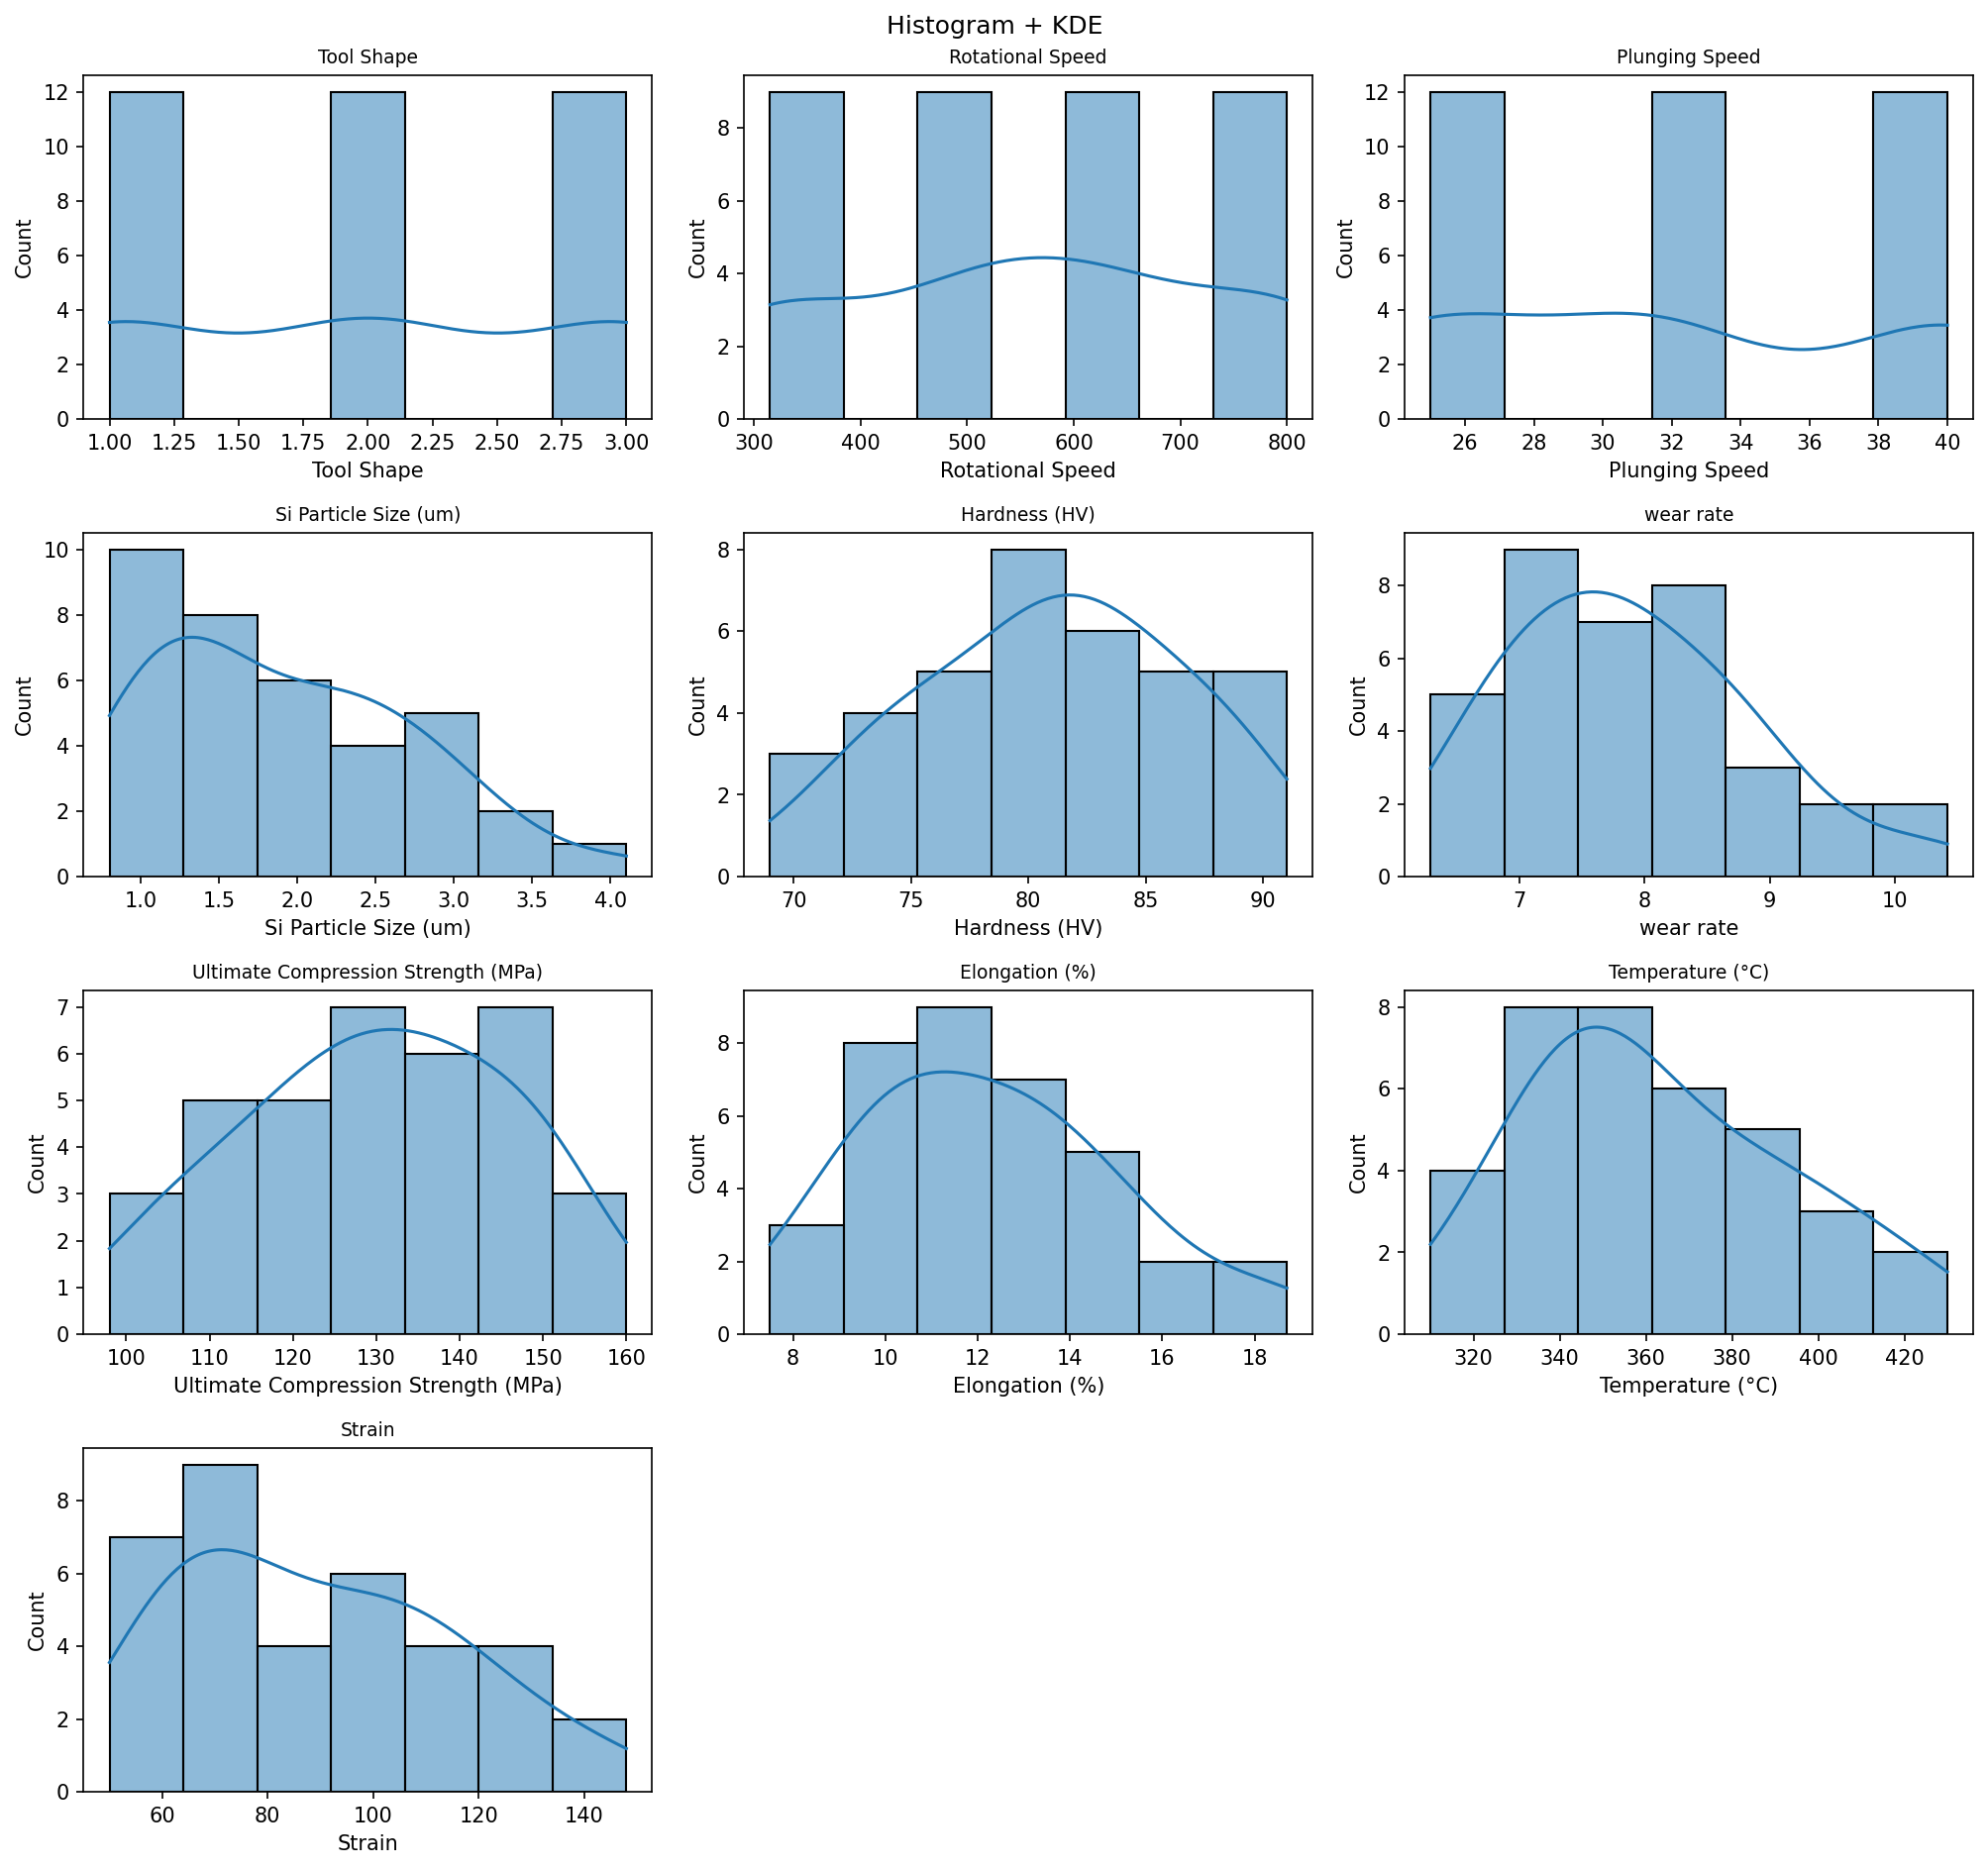

In [4]:
display(Image(filename=str(OUT_ROOT / 'Dataset_0136' / 'histograms_kde.png')))

Boxplot for every numeric variable.

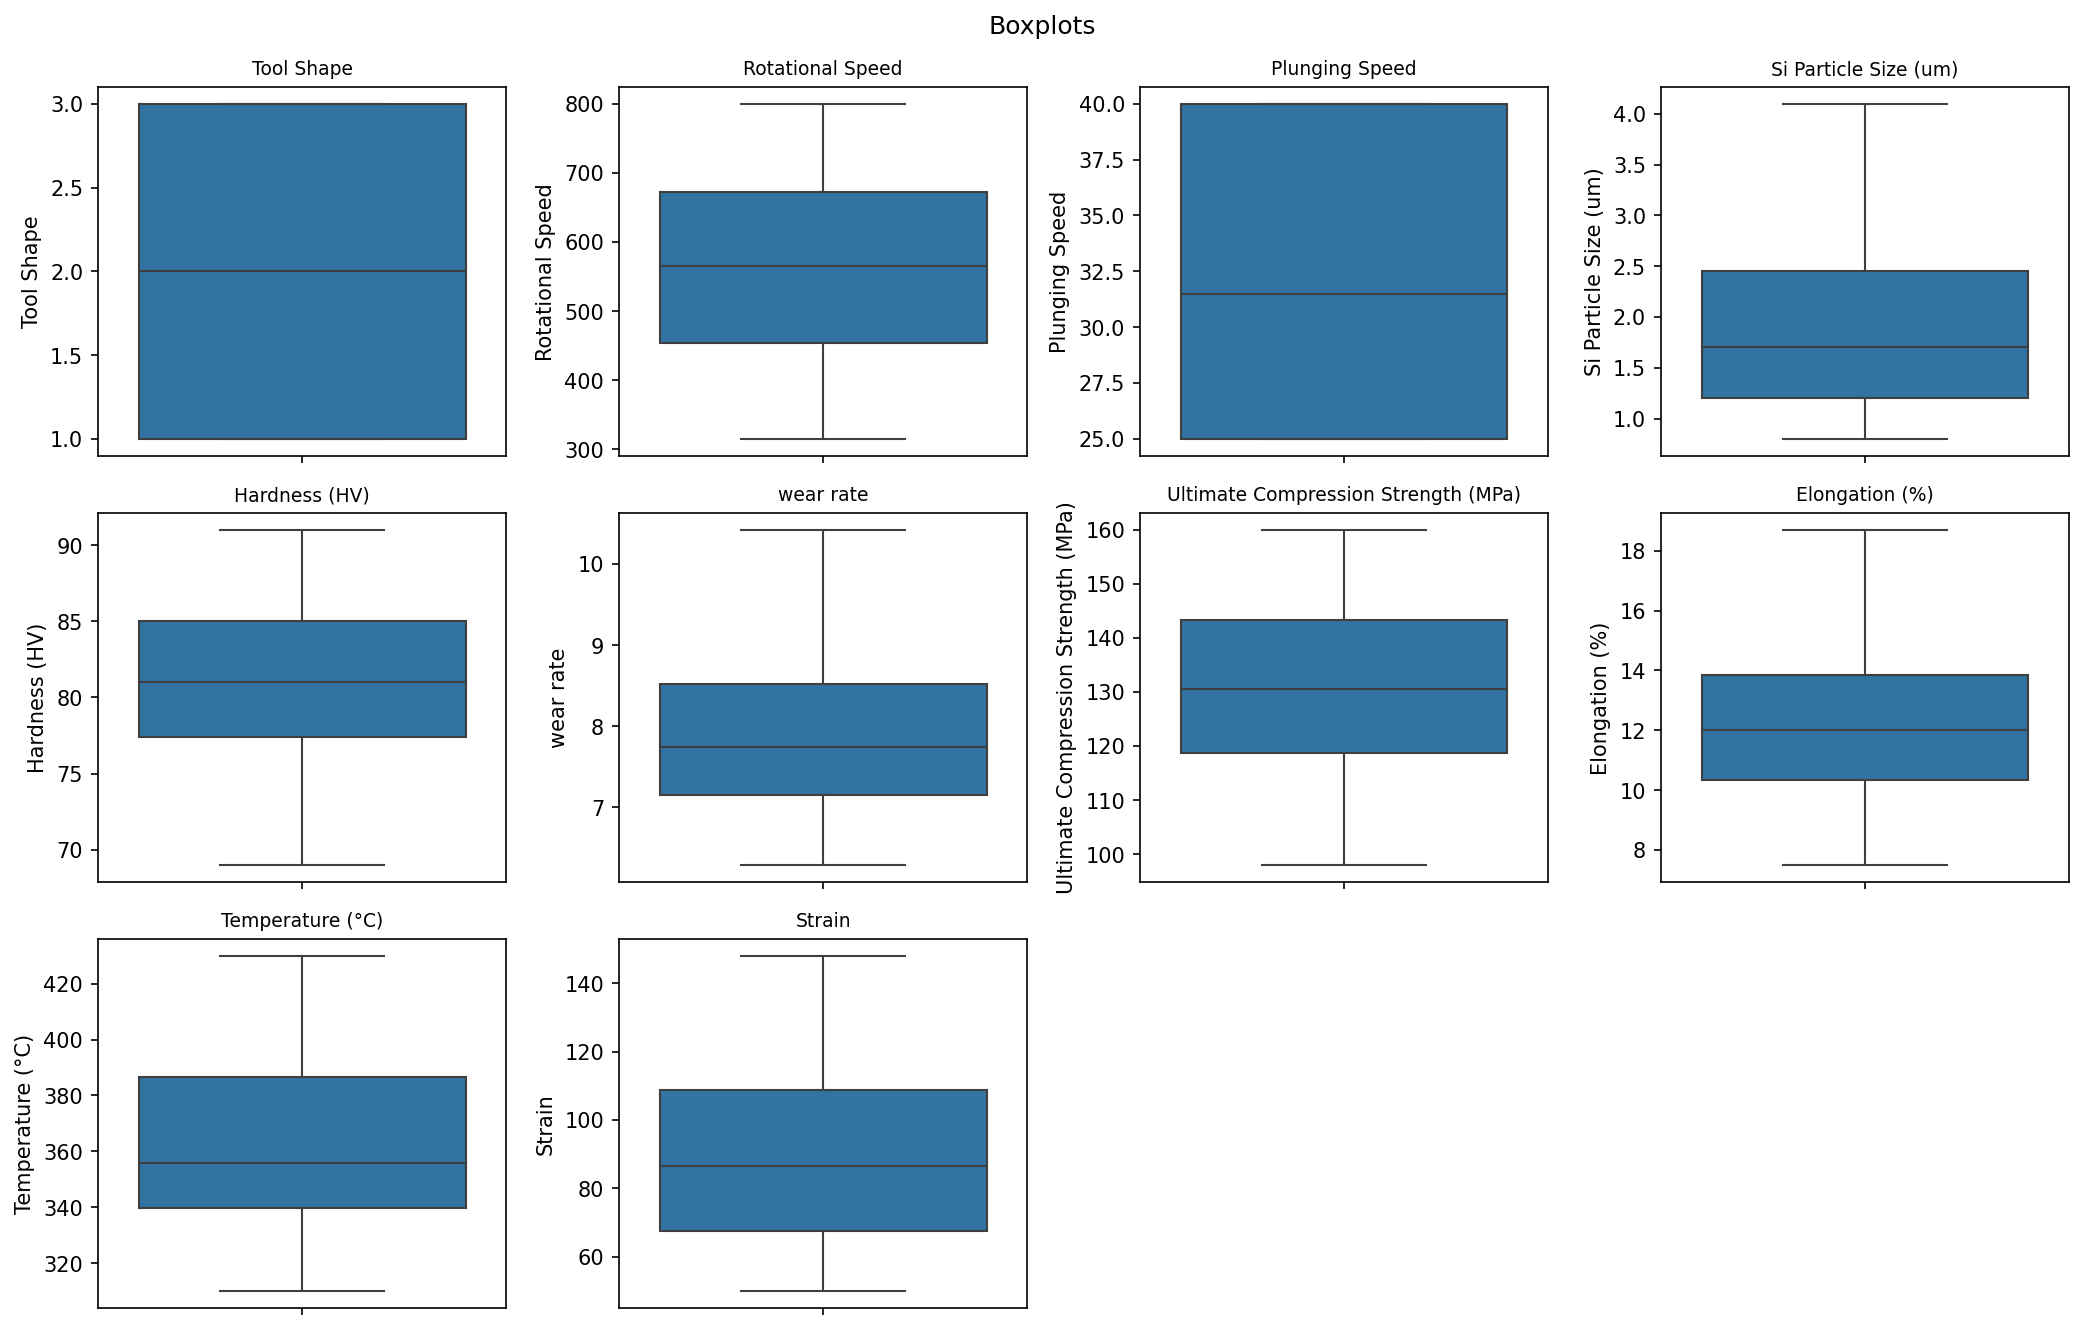

In [5]:
display(Image(filename=str(OUT_ROOT / 'Dataset_0136' / 'boxplots.png')))

QQ-plots against the normal distribution.

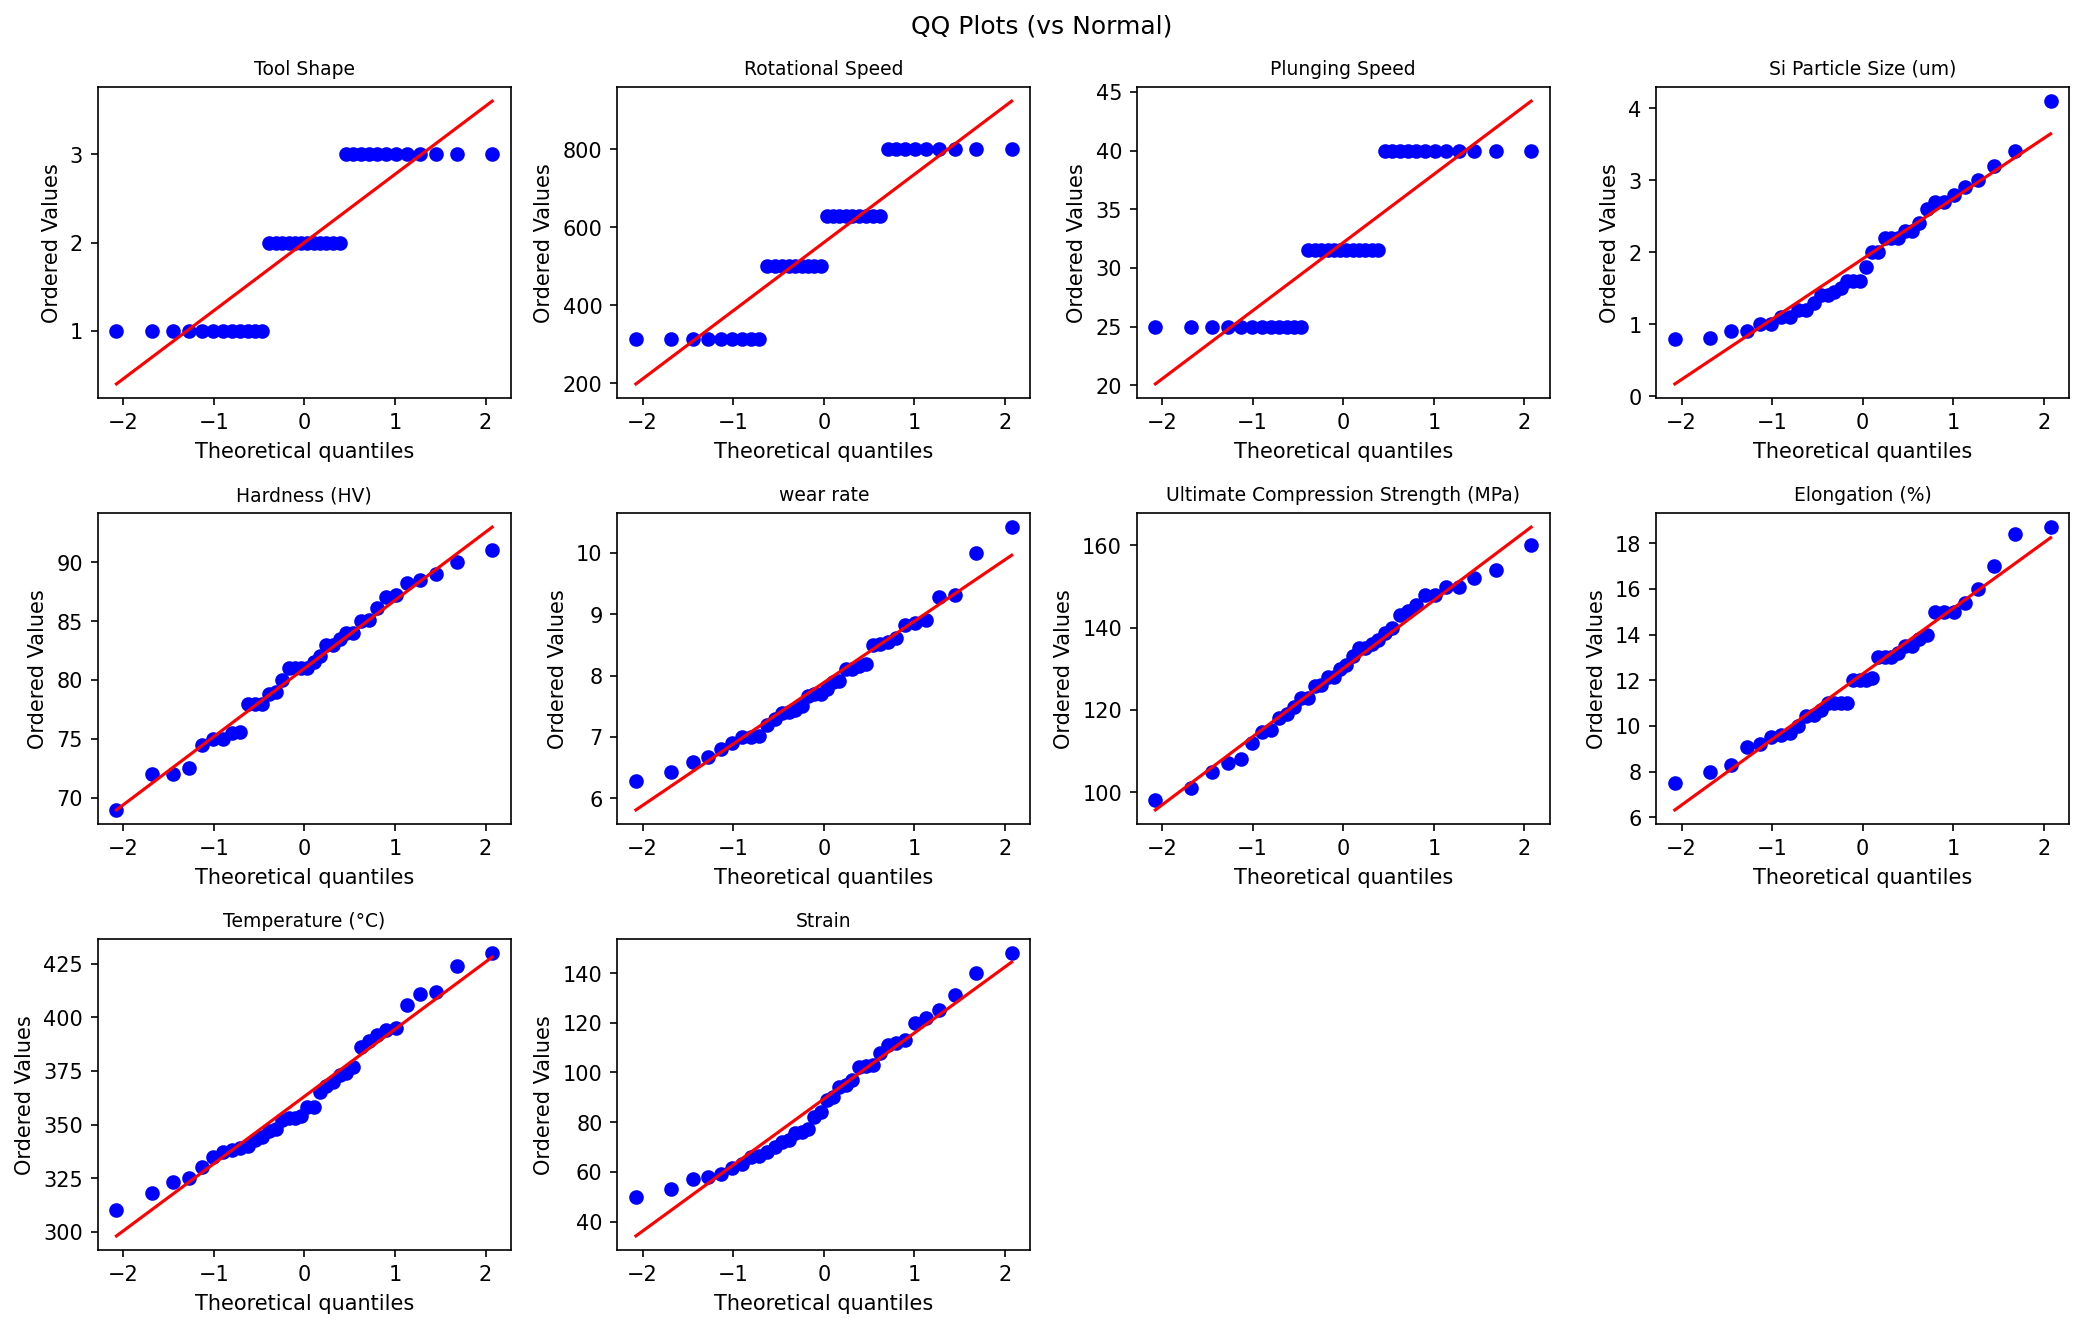

In [6]:
display(Image(filename=str(OUT_ROOT / 'Dataset_0136' / 'qq_plots.png')))

Pair plot of all numeric variables.

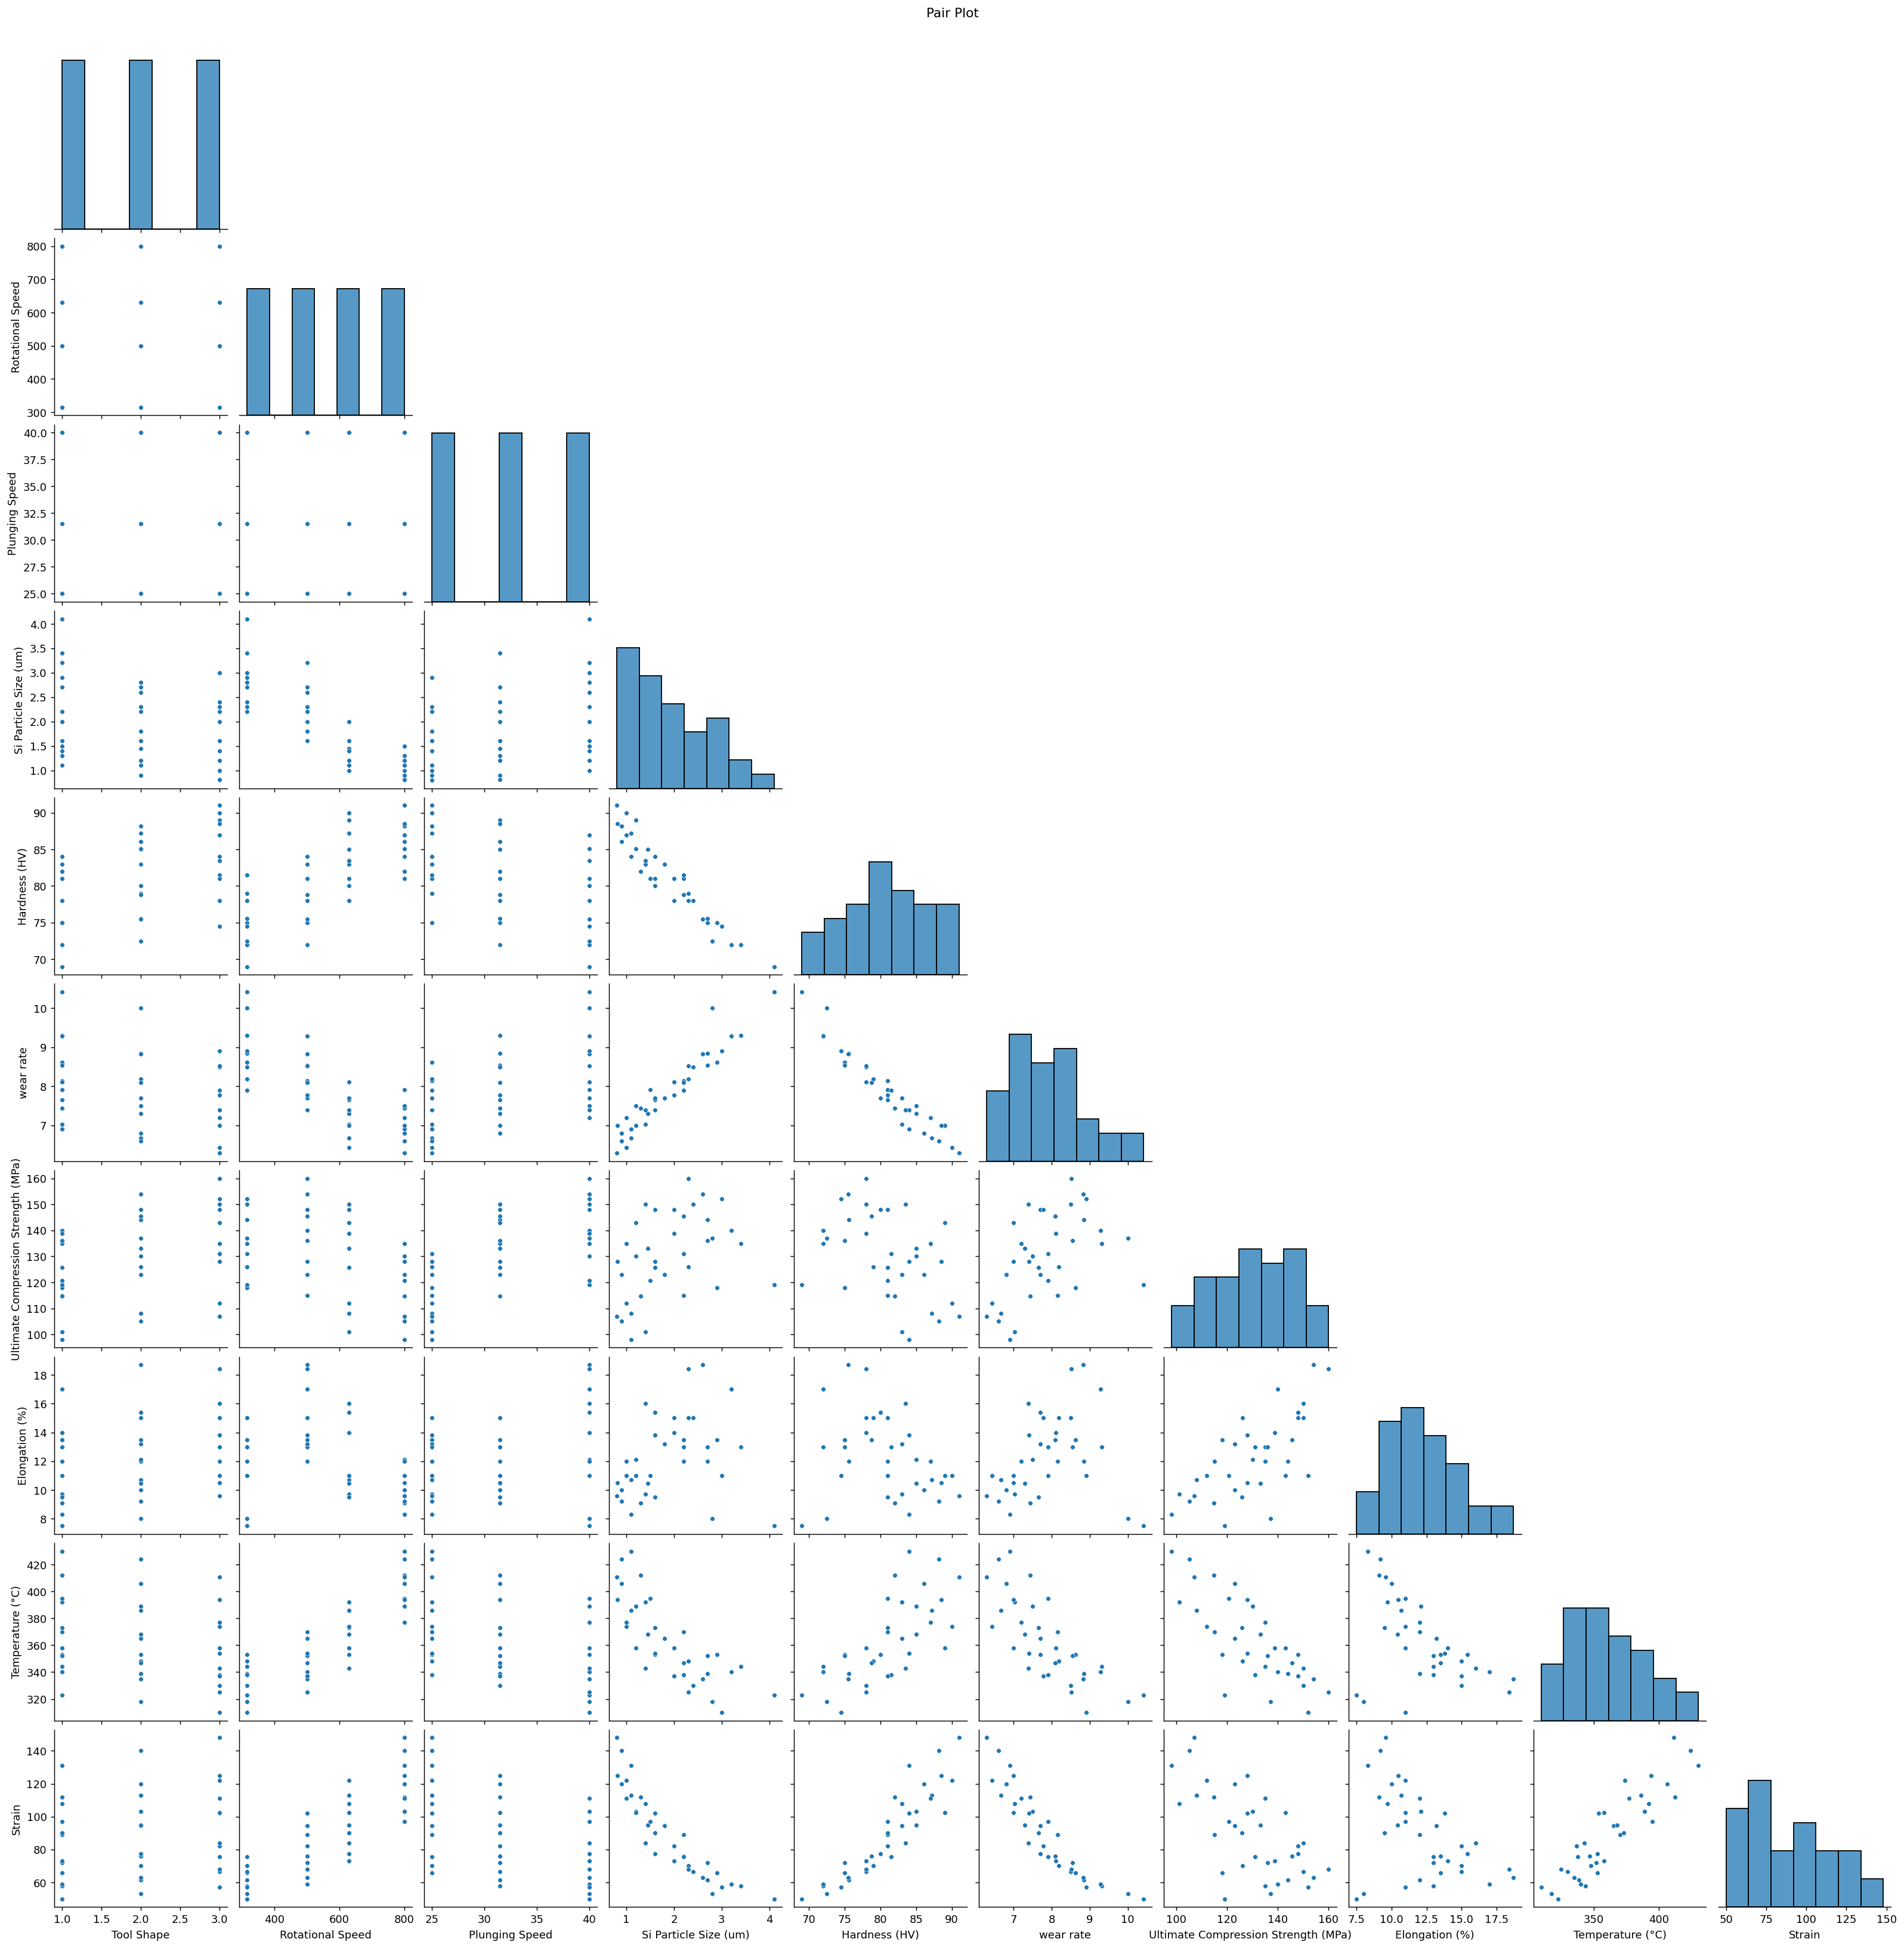

In [7]:
display(Image(filename=str(OUT_ROOT / 'Dataset_0136' / 'pairplot.png')))

Pearson / Spearman / Kendall correlation heatmaps.

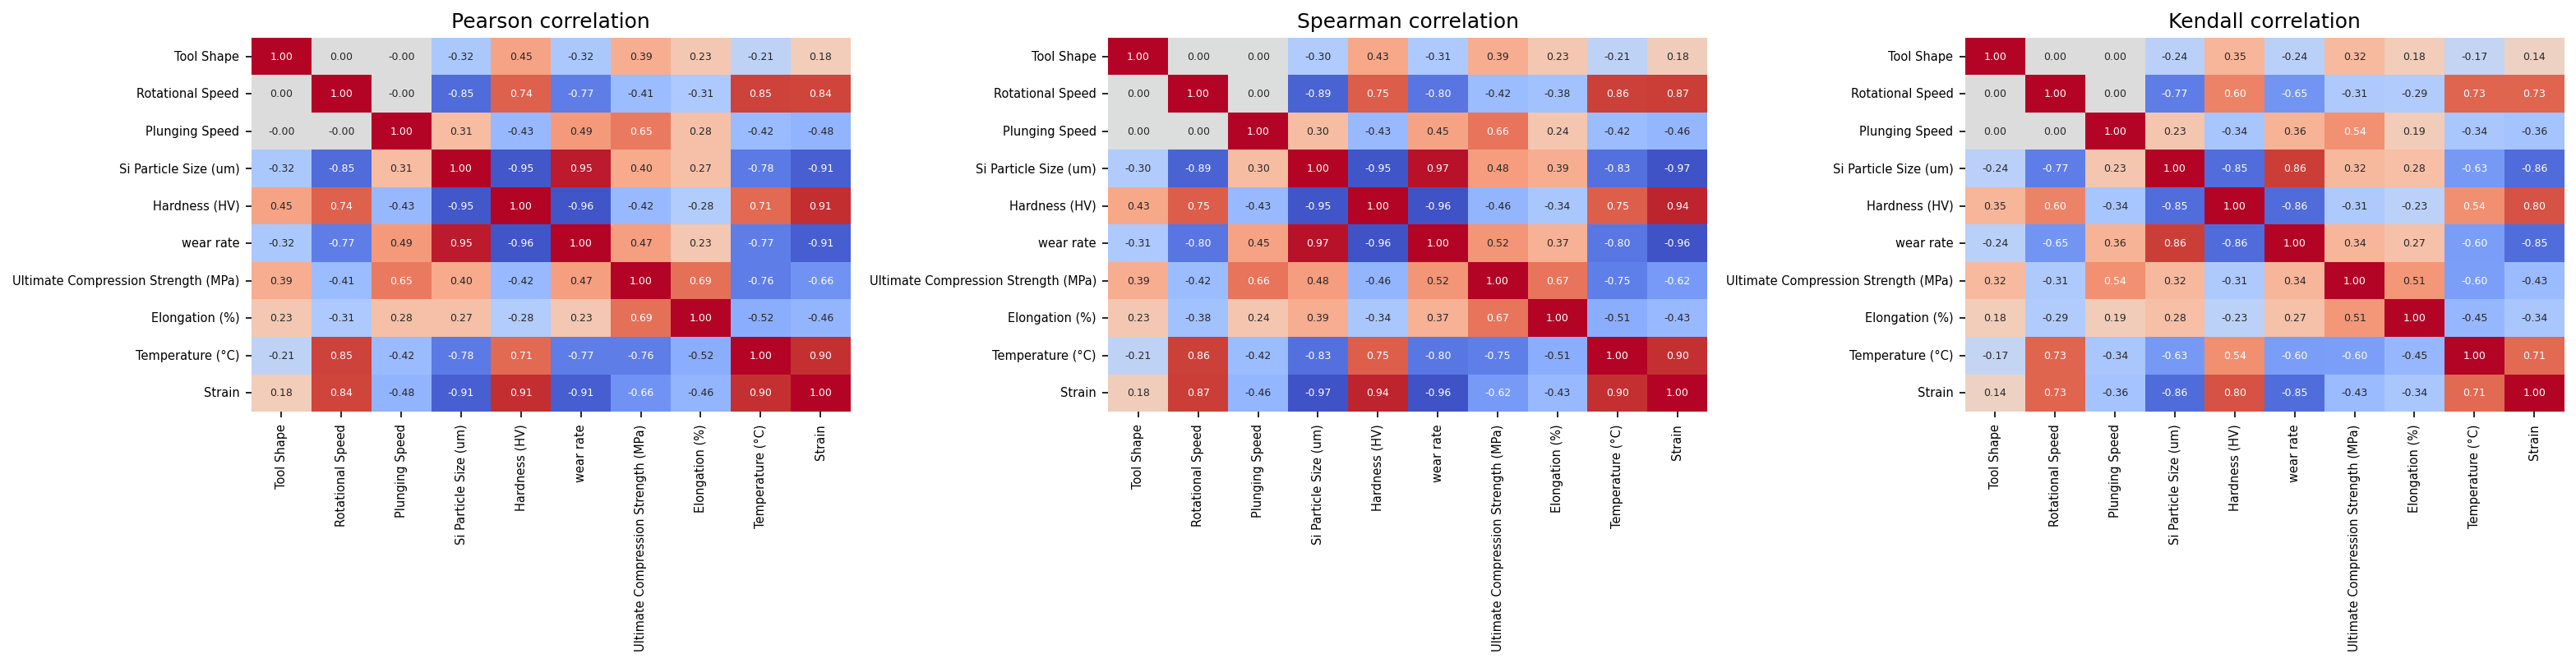

In [8]:
display(Image(filename=str(OUT_ROOT / 'Dataset_0136' / 'correlation_heatmaps.png')))

Descriptive statistics: mean, median, mode, variance, std, skewness, kurtosis.

In [9]:
desc_0136 = descriptive_statistics(df_0136)
desc_0136.to_csv(OUT_ROOT / 'Dataset_0136' / 'descriptive_statistics.csv')
desc_0136

,mean,median,mode,variance,std,skewness,kurtosis,min,max
Tool Shape,2.0000,2.00,1.0,0.6857,0.8281,0.0000,-1.5441,1.00,3.00
Rotational Speed,561.2500,565.00,315.0,32430.5357,180.0848,-0.0573,-1.2545,315.00,800.00
Plunging Speed,32.1667,31.50,25.0,38.8000,6.2290,0.1686,-1.5441,25.00,40.00
Si Particle Size (um),1.9072,1.70,1.6,0.6917,0.8317,0.6290,-0.2167,0.80,4.10
Hardness (HV),80.9708,81.00,81.0,31.6618,5.6269,-0.1688,-0.7005,69.00,91.00
wear rate,7.8866,7.74,7.0,0.9650,0.9823,0.6071,0.1189,6.29,10.42
Ultimate Compression Strength (MPa),130.0639,130.50,123.0,260.3681,16.1359,-0.1769,-0.7852,98.00,160.00
Elongation (%),12.2819,12.00,11.0,7.9020,2.8111,0.4736,-0.2403,7.50,18.70
Temperature (°C),363.0833,356.00,353.0,946.8786,30.7714,0.4640,-0.5452,310.00,430.00
Strain,89.3028,86.50,50.0,682.6106,26.1268,0.4502,-0.6964,50.00,148.00


Normality tests: Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov.

In [10]:
norm_0136 = normality_tests(df_0136)
norm_0136.to_csv(OUT_ROOT / 'Dataset_0136' / 'normality_tests.csv', index=False)
norm_0136

,variable,shapiro_stat,shapiro_p,anderson_stat,anderson_crit_5pct,ks_stat,ks_p,normal_at_5pct(shapiro)
0,Tool Shape,0.7945,0.0000,2.8596,0.721,0.2197,0.0525,False
1,Rotational Speed,0.8617,0.0004,1.6647,0.721,0.1643,0.2564,False
2,Plunging Speed,0.7899,0.0000,2.9571,0.721,0.2291,0.0384,False
3,Si Particle Size (um),0.9444,0.0698,0.5852,0.721,0.1441,0.4051,True
4,Hardness (HV),0.9793,0.7214,0.2110,0.721,0.0854,0.9353,True
5,wear rate,0.9687,0.3900,0.2916,0.721,0.0753,0.9772,True
6,Ultimate Compression Strength (MPa),0.9792,0.7181,0.1949,0.721,0.0664,0.9942,True
7,Elongation (%),0.9704,0.4366,0.3100,0.721,0.1203,0.6316,True
8,Temperature (°C),0.9657,0.3204,0.4342,0.721,0.1212,0.6225,True
9,Strain,0.9581,0.1881,0.4567,0.721,0.1201,0.6333,True


Correlation tests (Pearson, Spearman, Kendall), sorted by absolute Spearman rho.

In [11]:
corr_0136 = correlation_tests(df_0136)
corr_0136.to_csv(OUT_ROOT / 'Dataset_0136' / 'correlation_tests.csv', index=False)
corr_0136.sort_values('spearman_rho', key=abs, ascending=False)

,var_a,var_b,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p
29,Si Particle Size (um),Strain,-0.9059,0.0000,-0.9669,0.0000,-0.8572,0.0000
25,Si Particle Size (um),wear rate,0.9528,0.0000,0.9666,0.0000,0.8650,0.0000
30,Hardness (HV),wear rate,-0.9603,0.0000,-0.9640,0.0000,-0.8563,0.0000
38,wear rate,Strain,-0.9136,0.0000,-0.9598,0.0000,-0.8490,0.0000
24,Si Particle Size (um),Hardness (HV),-0.9518,0.0000,-0.9550,0.0000,-0.8451,0.0000
34,Hardness (HV),Strain,0.9114,0.0000,0.9367,0.0000,0.8004,0.0000
44,Temperature (°C),Strain,0.9026,0.0000,0.9020,0.0000,0.7122,0.0000
10,Rotational Speed,Si Particle Size (um),-0.8523,0.0000,-0.8906,0.0000,-0.7676,0.0000
16,Rotational Speed,Strain,0.8409,0.0000,0.8658,0.0000,0.7301,0.0000
15,Rotational Speed,Temperature (°C),0.8502,0.0000,0.8611,0.0000,0.7295,0.0000


Bootstrap confidence intervals for Kendall's tau (95%).

In [12]:
kci_0136 = kendall_ci_table(df_0136)
kci_0136.to_csv(OUT_ROOT / 'Dataset_0136' / 'kendall_confidence_intervals.csv', index=False)
kci_0136

,var_a,var_b,tau,p_value,ci_lower,ci_upper
0,Tool Shape,Rotational Speed,0.0000,1.0000,-0.3073,0.2810
1,Tool Shape,Plunging Speed,0.0000,1.0000,-0.3054,0.2834
2,Tool Shape,Si Particle Size (um),-0.2404,0.0717,-0.4756,0.0319
3,Tool Shape,Hardness (HV),0.3467,0.0093,0.1047,0.5620
4,Tool Shape,wear rate,-0.2419,0.0675,-0.4633,-0.0020
5,Tool Shape,Ultimate Compression Strength (MPa),0.3156,0.0173,0.0533,0.5435
6,Tool Shape,Elongation (%),0.1845,0.1675,-0.0814,0.4309
7,Tool Shape,Temperature (°C),-0.1728,0.1916,-0.4305,0.0935
8,Tool Shape,Strain,0.1418,0.2831,-0.1239,0.3887
9,Rotational Speed,Plunging Speed,0.0000,1.0000,-0.2946,0.2923


Outlier detection with IQR, LOF and Isolation Forest — samples are flagged, never removed.

In [13]:
outl_0136 = outlier_report(df_0136)
outl_0136.to_csv(OUT_ROOT / 'Dataset_0136' / 'outlier_report.csv')
flagged_0136 = outl_0136[outl_0136['n_methods_flagging'] > 0]
print(f'{len(flagged_0136)} of {len(outl_0136)} samples flagged by at least one method')
flagged_0136

4 of 36 samples flagged by at least one method


,iqr_outlier,lof_outlier,iforest_outlier,n_methods_flagging
2,False,False,True,1
5,False,False,True,1
26,False,False,True,1
33,False,False,True,1


## Dataset_0172

Load the dataset; the loader drops the `No.` index column and constant input features.

In [14]:
bundle_0172 = load_dataset('Dataset_0172')
df_0172 = pd.concat([bundle_0172.X, bundle_0172.Y], axis=1)
print('Shape:', df_0172.shape)
print('Inputs :', bundle_0172.feature_names)
print('Outputs:', bundle_0172.output_names)
print('Dropped constant features:', bundle_0172.dropped_constant_features)
df_0172.head()

Shape: (72, 9)
Inputs : ['Tool Shape', 'Rotational Speed', 'Plunging Speed', 'Composite Volume Fraction (%)']
Outputs: ['Si Particle Size (um)', 'Hardness (HV)', 'wear rate', 'Ultimate Compression Strength (MPa)', 'Elongation (%)']
Dropped constant features: []


,Tool Shape,Rotational Speed,Plunging Speed,Composite Volume Fraction (%),Si Particle Size (um),Hardness (HV),wear rate,Ultimate Compression Strength (MPa),Elongation (%)
0,1,315,25.0,0,2.9,75.0,8.62,118.0,13.5
1,1,315,31.5,0,3.4,72.0,9.31,135.0,13.0
2,1,315,40.0,0,4.1,69.0,10.42,119.0,7.5
3,1,500,25.0,0,2.2,81.0,8.15,115.0,12.0
4,1,500,31.5,0,2.7,75.0,8.54,136.0,13.0


Generate and save all EDA figures for this dataset.

In [15]:
run_all_visualizations(df_0172, OUT_ROOT / 'Dataset_0172')
print('Figures saved to:', OUT_ROOT / 'Dataset_0172')

Figures saved to: C:\Users\mohammadhosein\Desktop\DeepLearning-miniProject\results\eda\Dataset_0172


Histogram + KDE for every numeric variable.

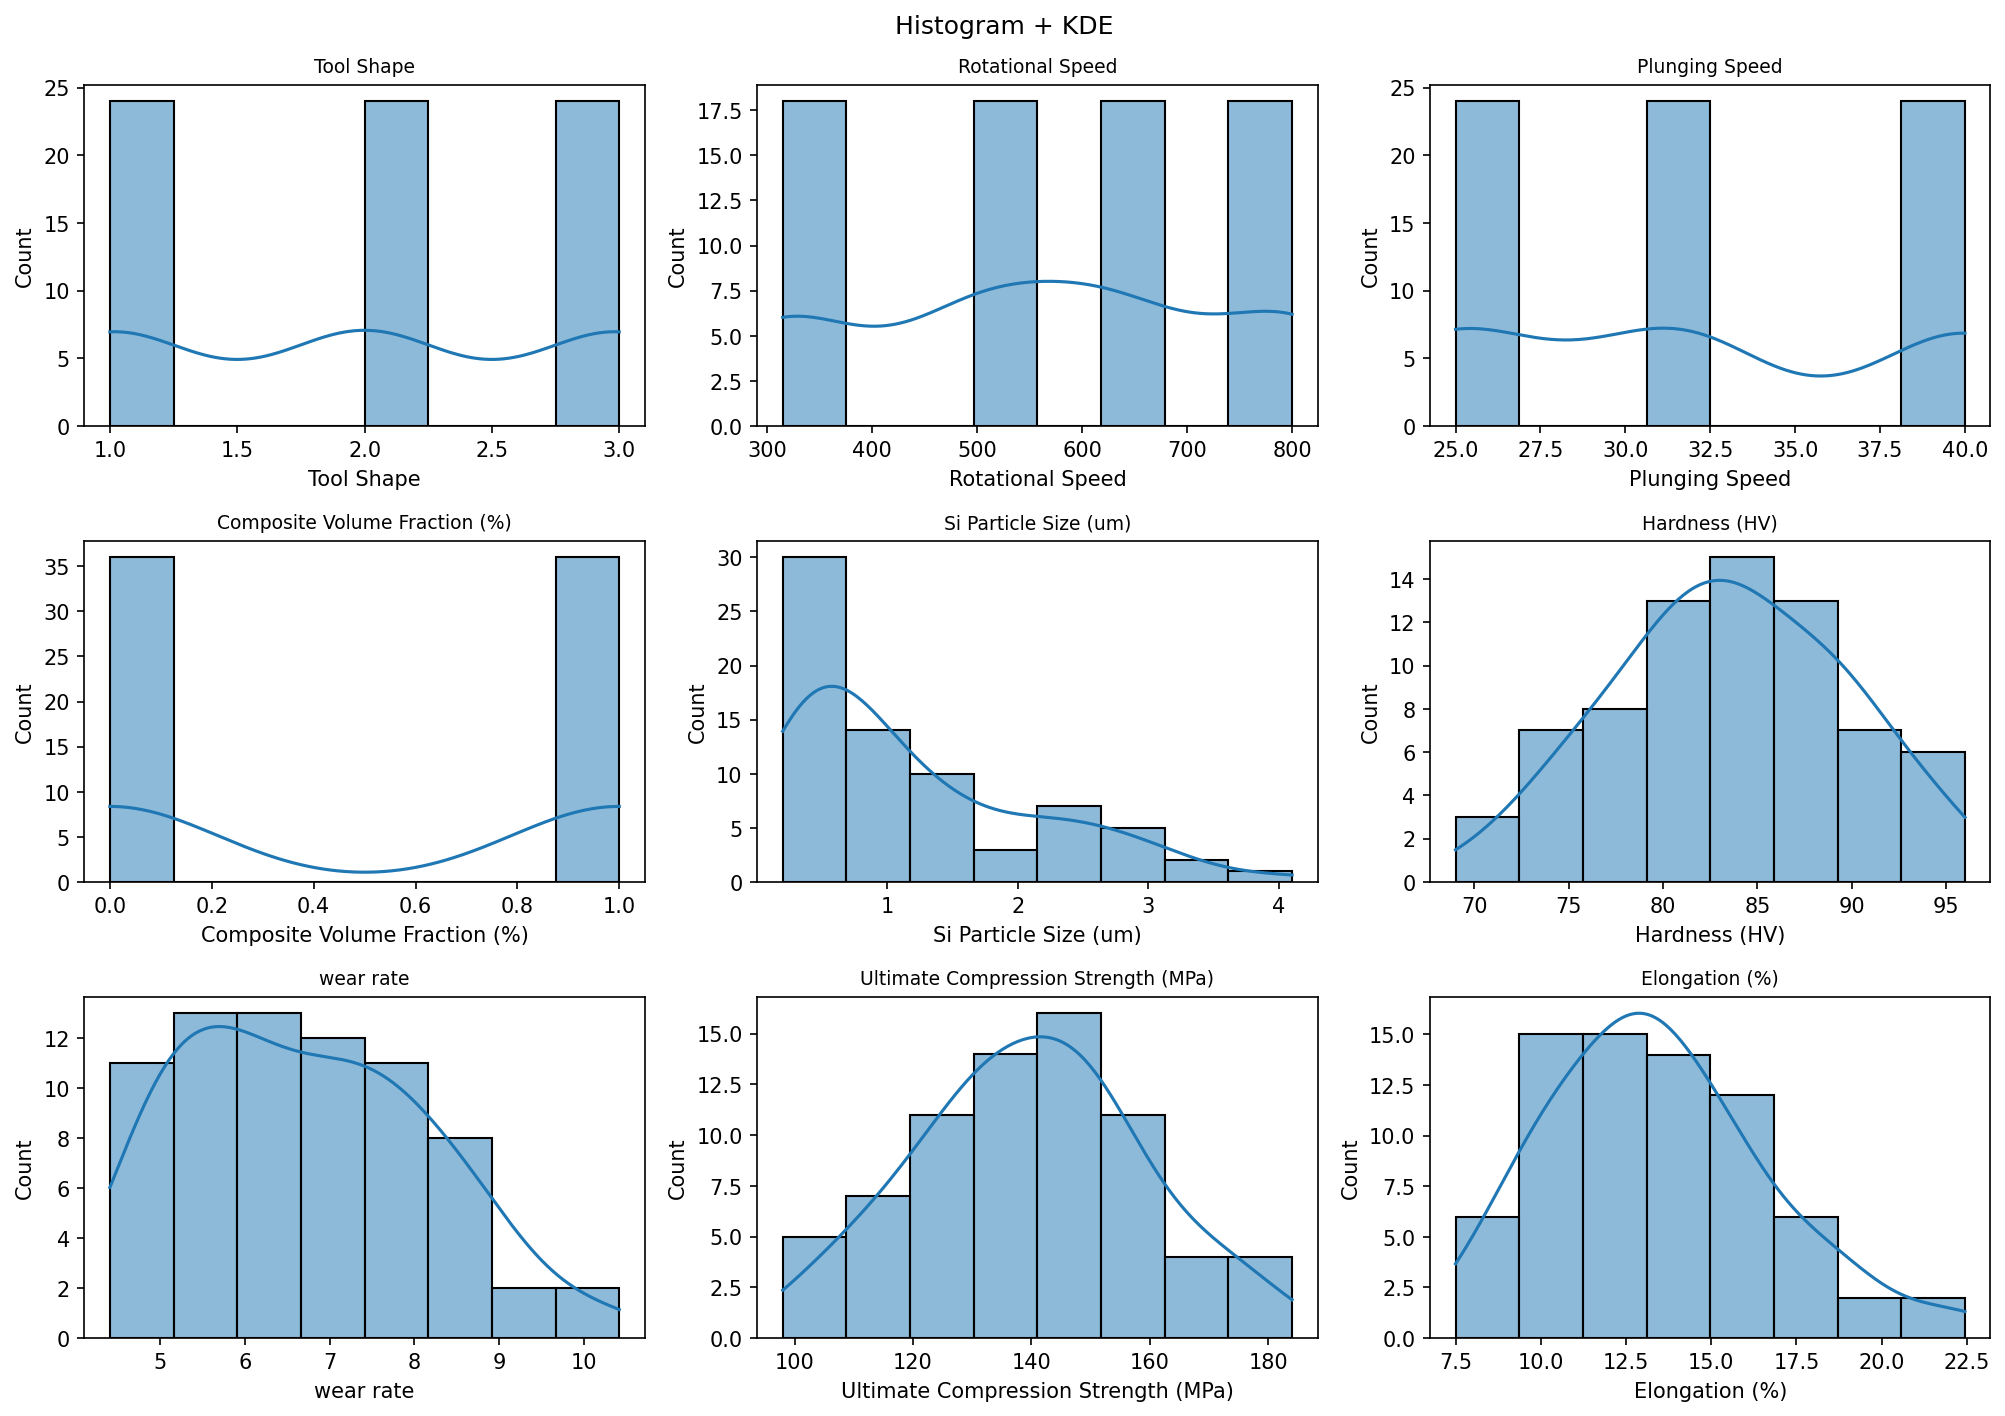

In [16]:
display(Image(filename=str(OUT_ROOT / 'Dataset_0172' / 'histograms_kde.png')))

Boxplot for every numeric variable.

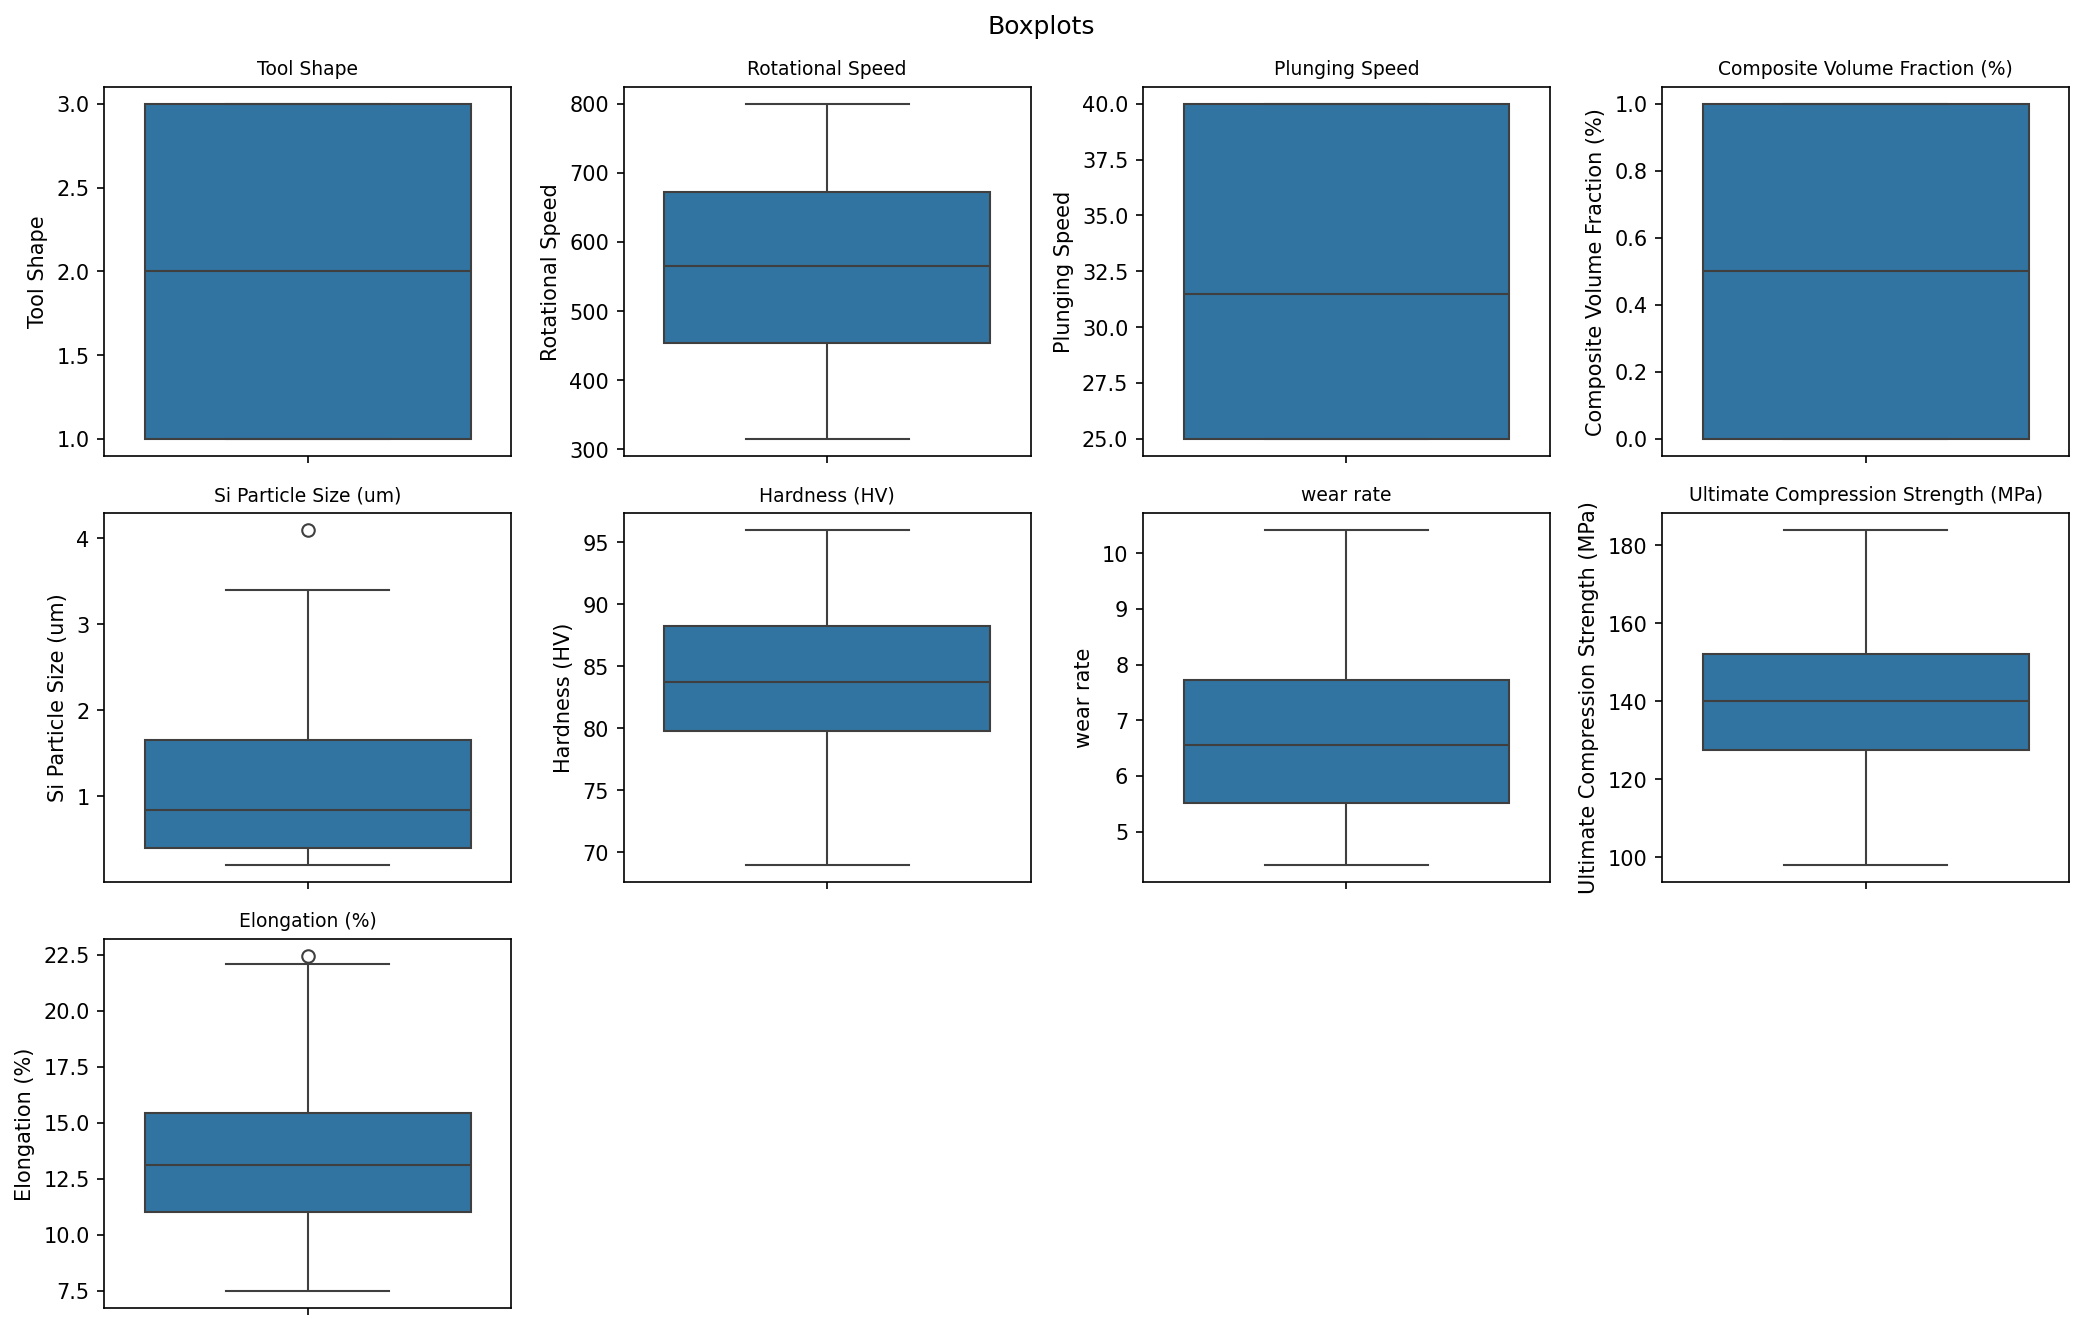

In [17]:
display(Image(filename=str(OUT_ROOT / 'Dataset_0172' / 'boxplots.png')))

QQ-plots against the normal distribution.

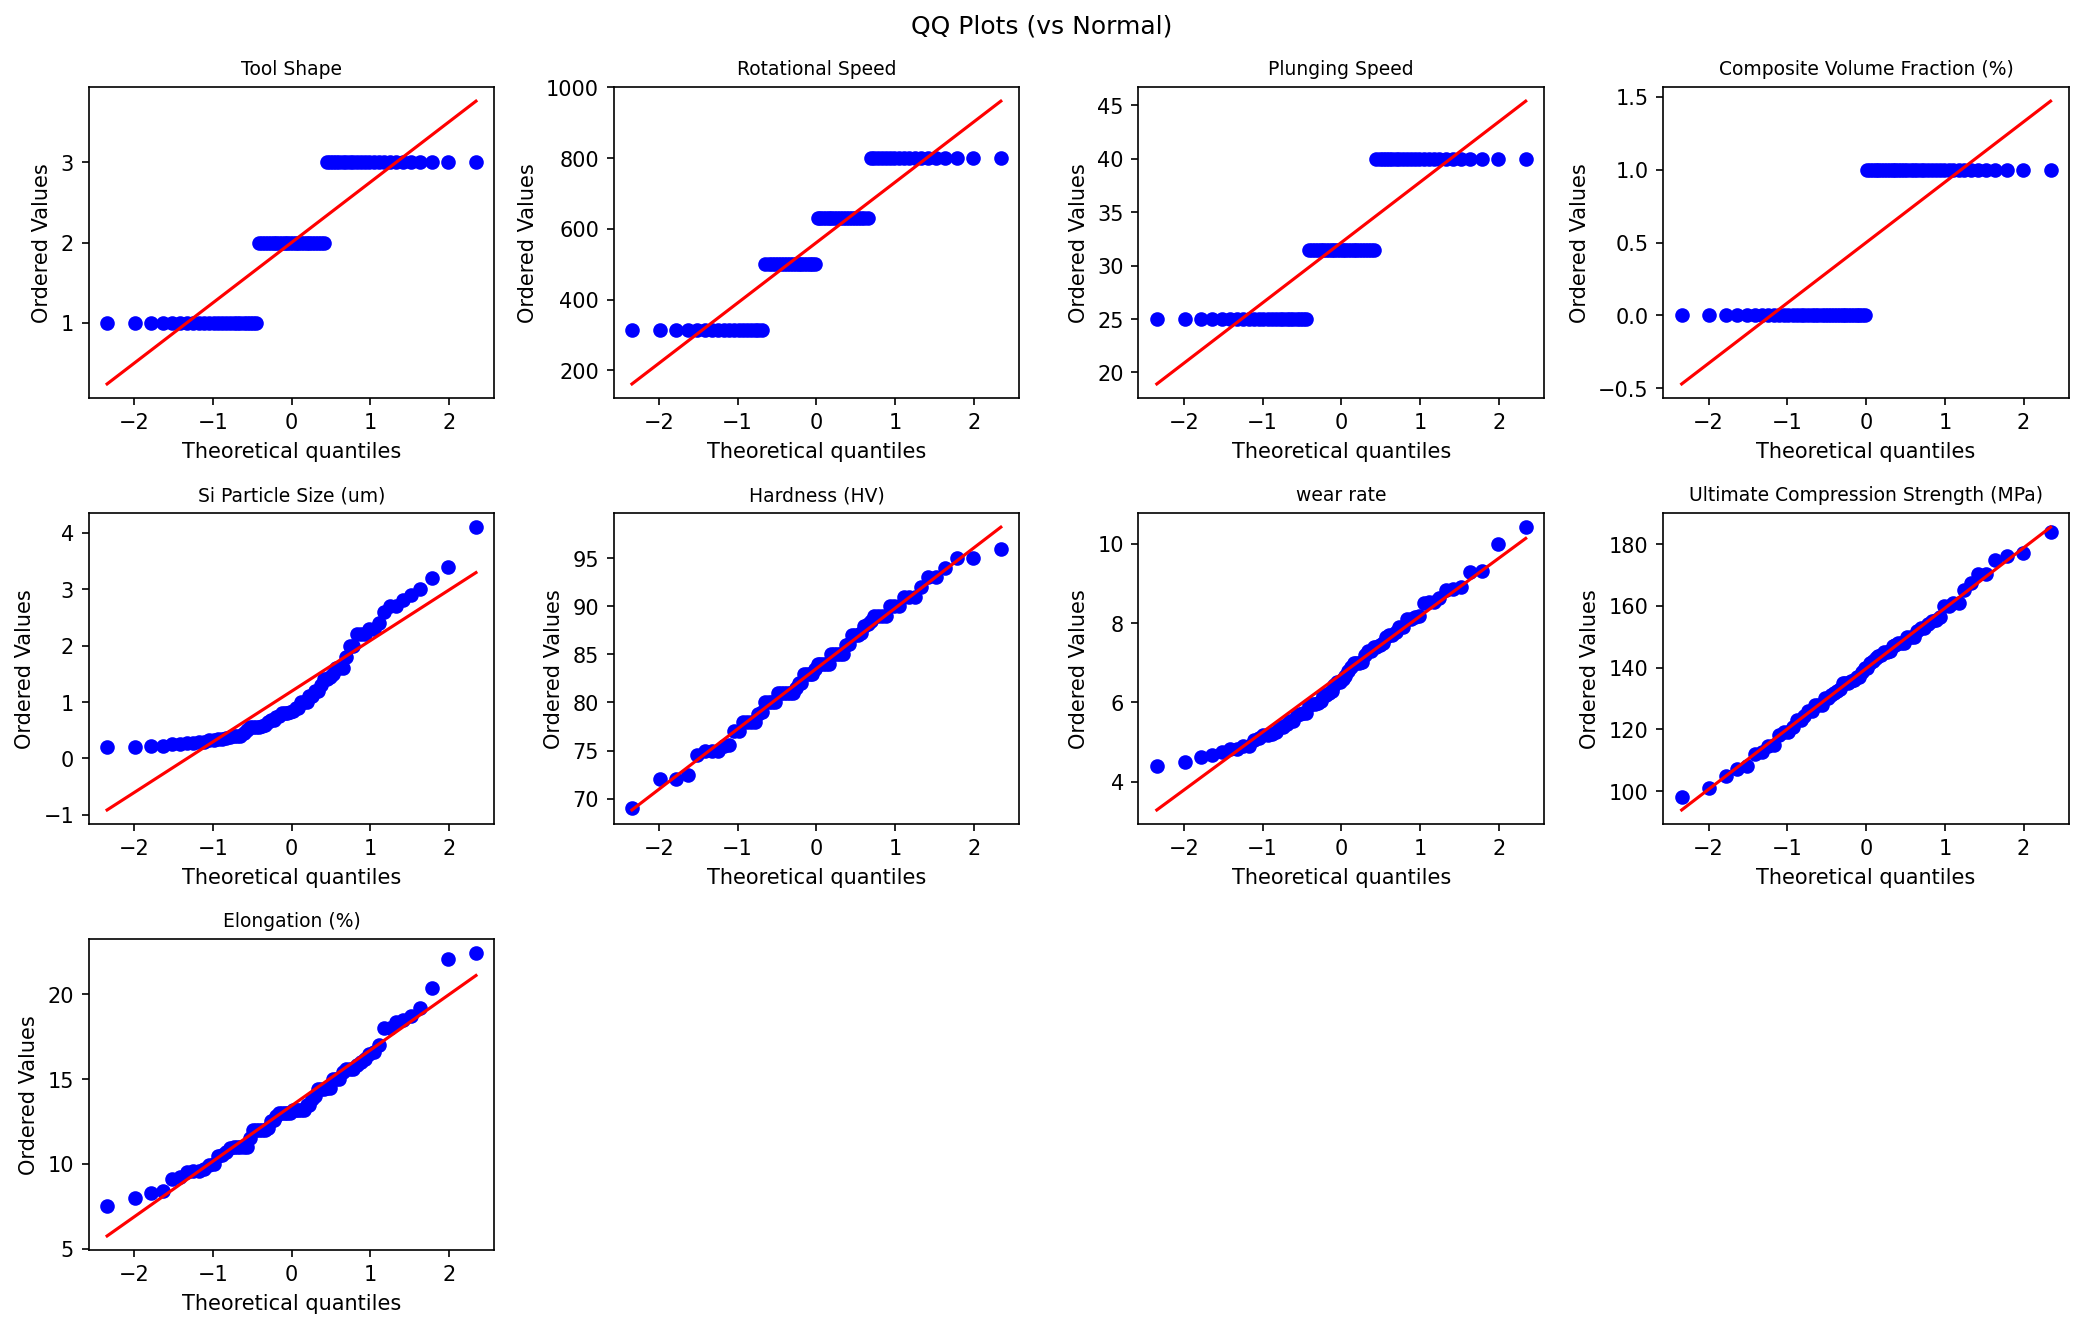

In [18]:
display(Image(filename=str(OUT_ROOT / 'Dataset_0172' / 'qq_plots.png')))

Pair plot of all numeric variables.

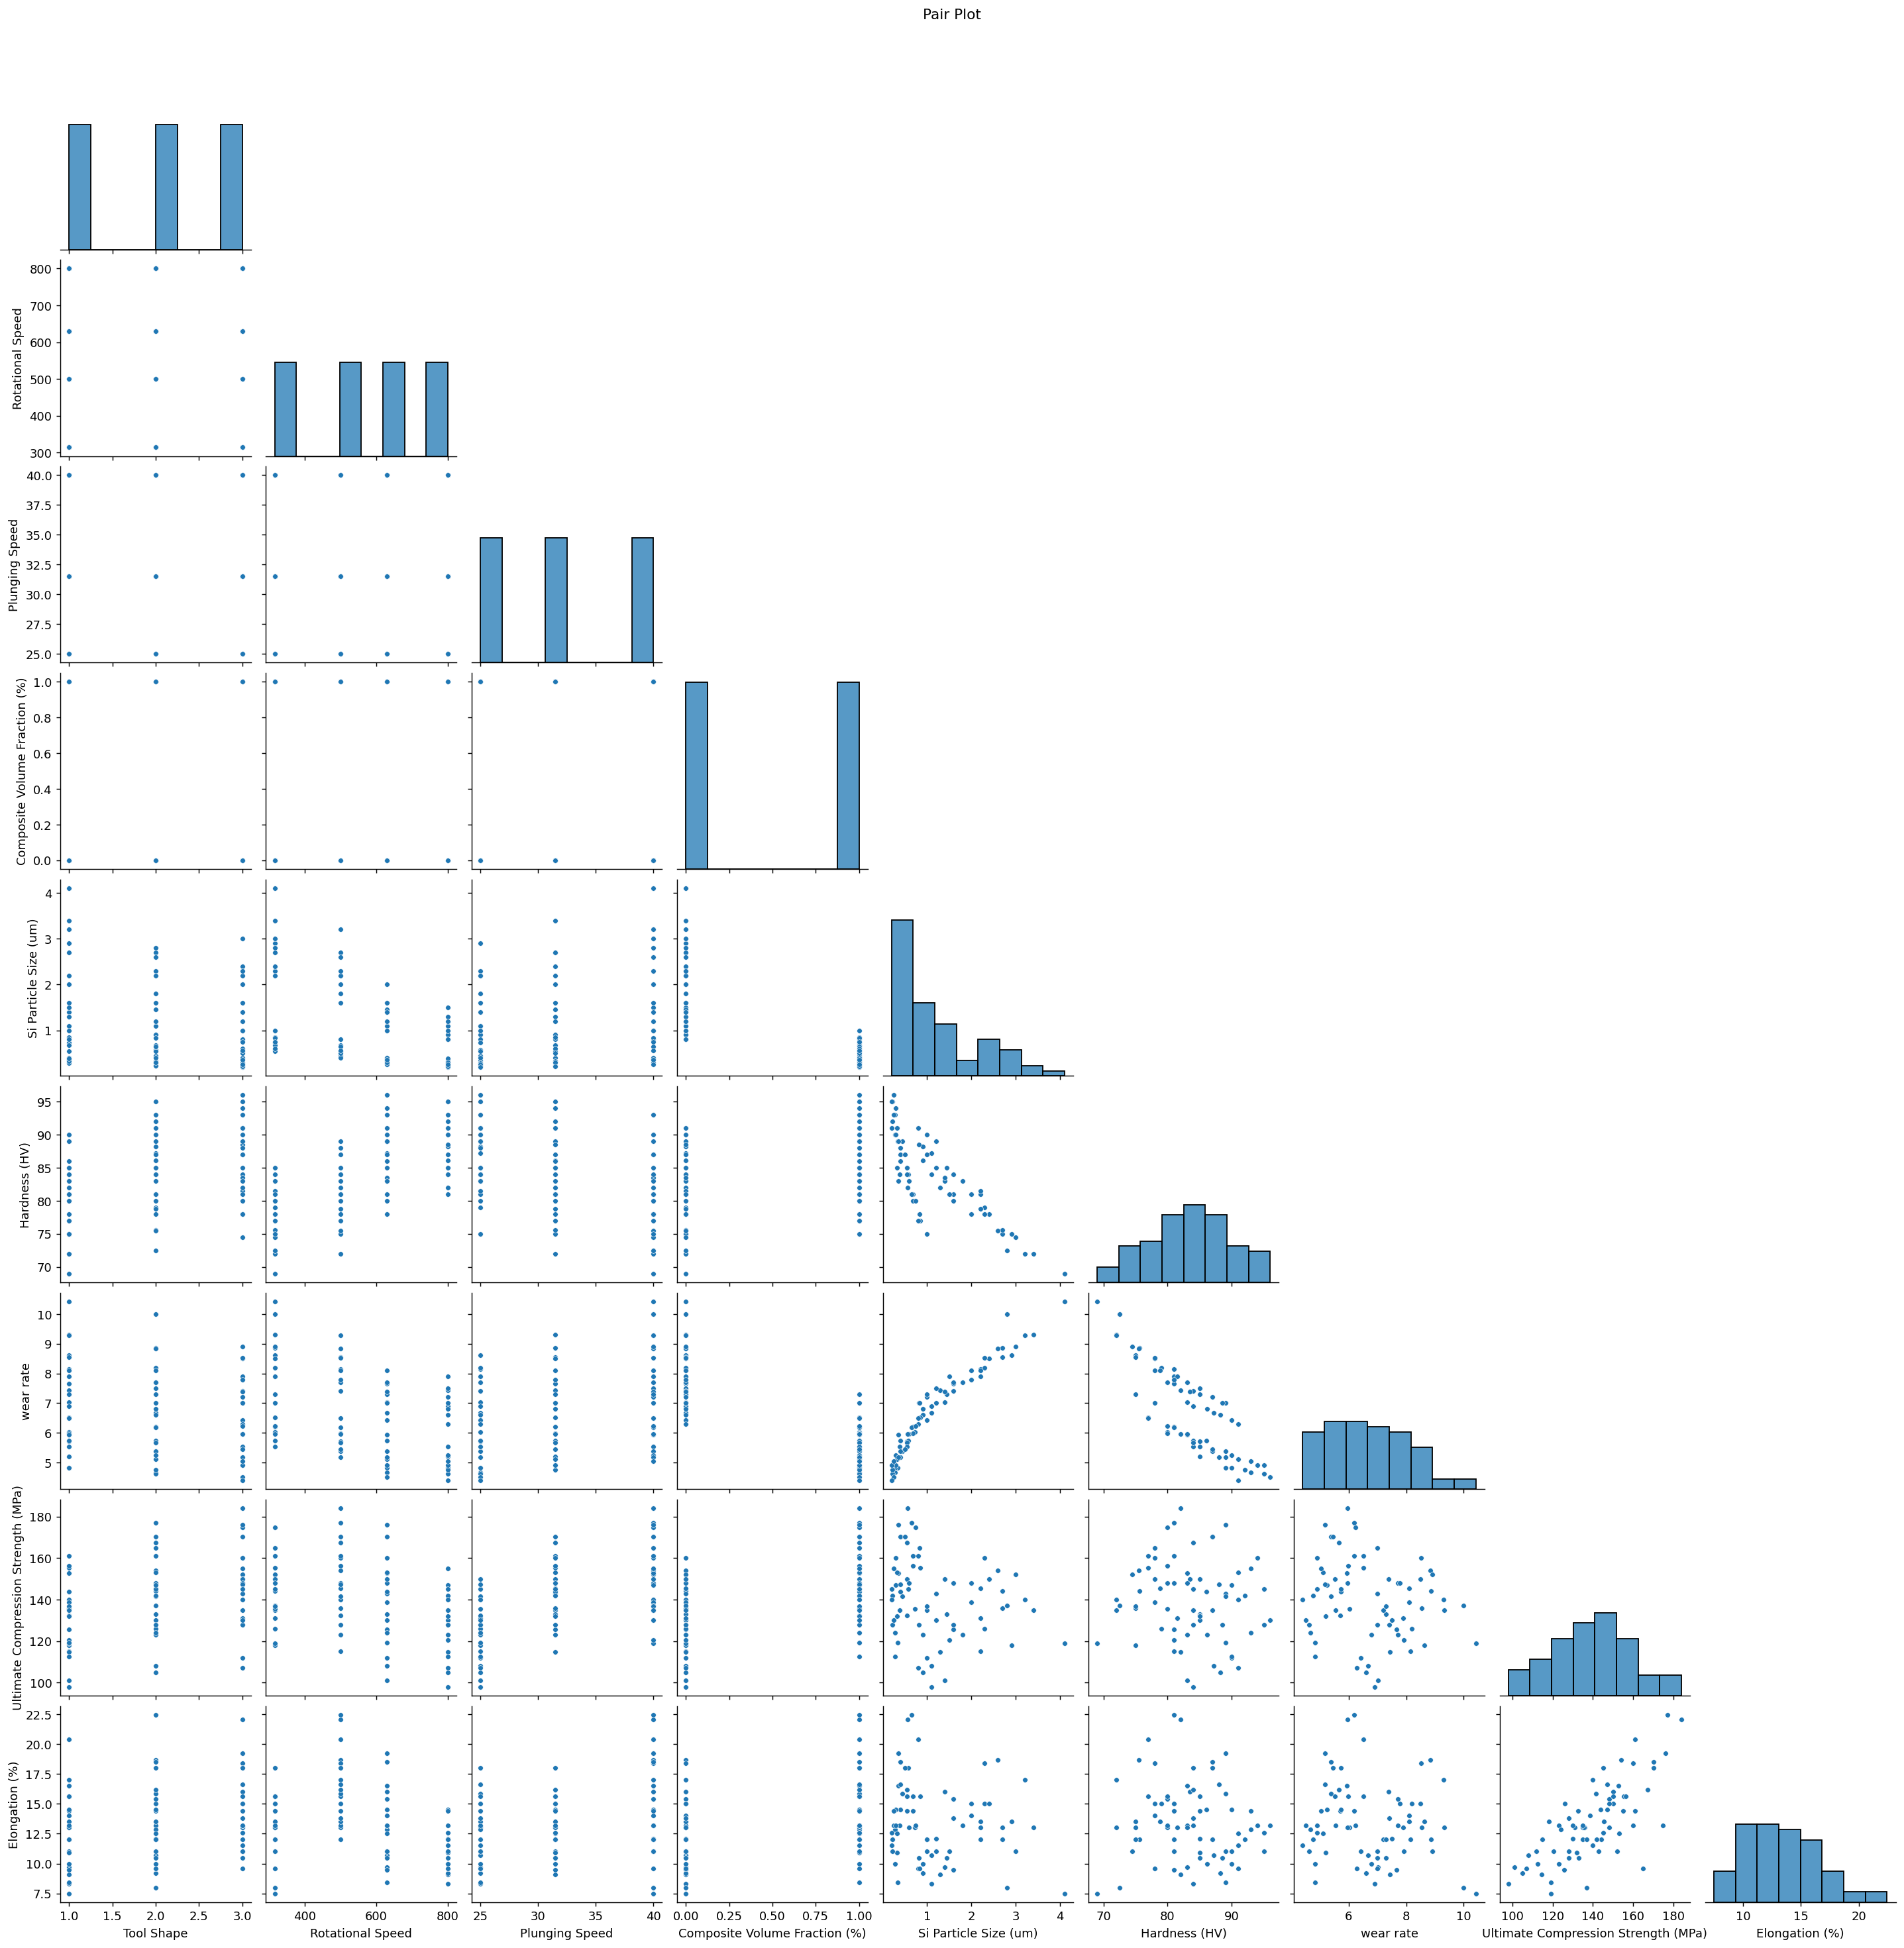

In [19]:
display(Image(filename=str(OUT_ROOT / 'Dataset_0172' / 'pairplot.png')))

Pearson / Spearman / Kendall correlation heatmaps.

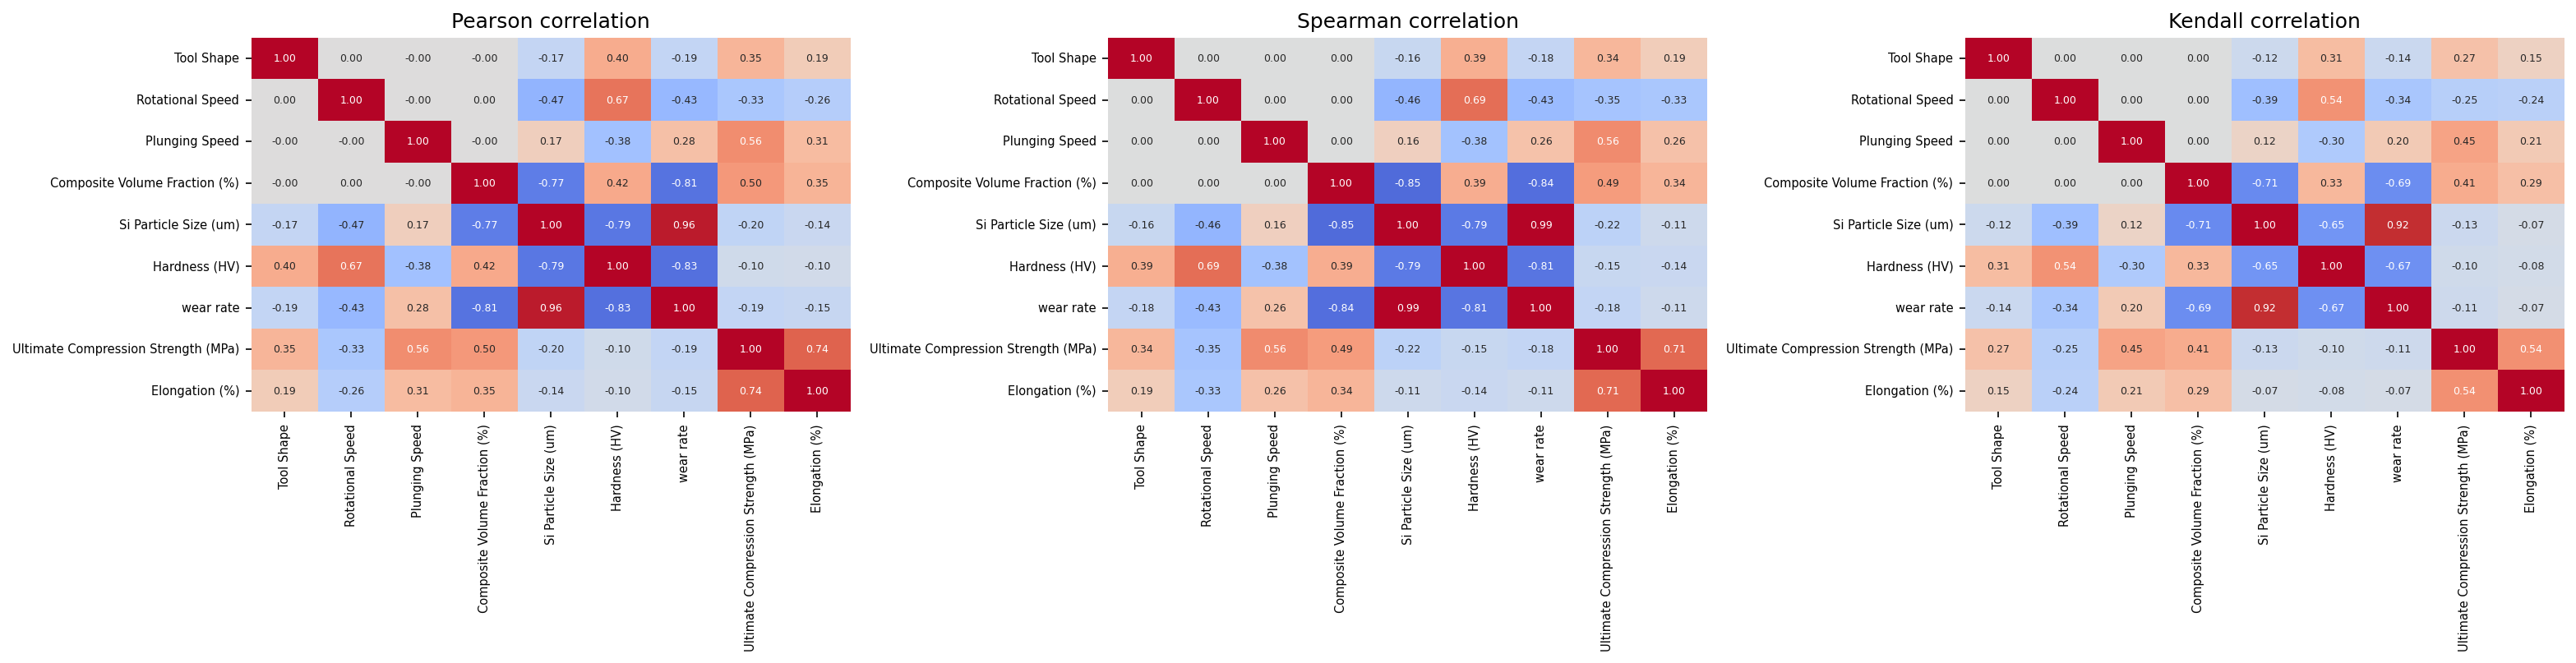

In [20]:
display(Image(filename=str(OUT_ROOT / 'Dataset_0172' / 'correlation_heatmaps.png')))

Descriptive statistics: mean, median, mode, variance, std, skewness, kurtosis.

In [21]:
desc_0172 = descriptive_statistics(df_0172)
desc_0172.to_csv(OUT_ROOT / 'Dataset_0172' / 'descriptive_statistics.csv')
desc_0172

,mean,median,mode,variance,std,skewness,kurtosis,min,max
Tool Shape,2.0000,2.0000,1.0,0.6761,0.8222,0.0000,-1.5214,1.000,3.00
Rotational Speed,561.2500,565.0000,315.0,31973.7676,178.8121,-0.0560,-1.2521,315.000,800.00
Plunging Speed,32.1667,31.5000,25.0,38.2535,6.1849,0.1650,-1.5214,25.000,40.00
Composite Volume Fraction (%),0.5000,0.5000,0.0,0.2535,0.5035,0.0000,-2.0580,0.000,1.00
Si Particle Size (um),1.1913,0.8400,0.4,0.8830,0.9397,1.0609,0.3130,0.200,4.10
Hardness (HV),83.5271,83.7500,81.0,38.1322,6.1751,-0.0690,-0.5278,69.000,96.00
wear rate,6.7111,6.5585,7.0,2.1139,1.4539,0.3987,-0.6110,4.403,10.42
Ultimate Compression Strength (MPa),139.6782,140.0000,128.0,368.9714,19.2086,0.0356,-0.3441,98.000,184.00
Elongation (%),13.4315,13.1000,11.0,10.6440,3.2625,0.5958,0.2325,7.500,22.44


Normality tests: Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov.

In [22]:
norm_0172 = normality_tests(df_0172)
norm_0172.to_csv(OUT_ROOT / 'Dataset_0172' / 'normality_tests.csv', index=False)
norm_0172

,variable,shapiro_stat,shapiro_p,anderson_stat,anderson_crit_5pct,ks_stat,ks_p,normal_at_5pct(shapiro)
0,Tool Shape,0.7931,0.0000,5.8044,0.749,0.2214,0.0014,False
1,Rotational Speed,0.8599,0.0000,3.3850,0.749,0.1658,0.0338,False
2,Plunging Speed,0.7884,0.0000,6.0009,0.749,0.2307,0.0008,False
3,Composite Volume Fraction (%),0.6365,0.0000,12.7697,0.749,0.3397,0.0000,False
4,Si Particle Size (um),0.8738,0.0000,3.0992,0.749,0.1640,0.0368,False
5,Hardness (HV),0.9888,0.7748,0.1873,0.749,0.0484,0.9930,True
6,wear rate,0.9665,0.0521,0.6271,0.749,0.0828,0.6762,True
7,Ultimate Compression Strength (MPa),0.9931,0.9662,0.0923,0.749,0.0316,1.0000,True
8,Elongation (%),0.9711,0.0962,0.5164,0.749,0.0977,0.4681,True


Correlation tests (Pearson, Spearman, Kendall), sorted by absolute Spearman rho.

In [23]:
corr_0172 = correlation_tests(df_0172)
corr_0172.to_csv(OUT_ROOT / 'Dataset_0172' / 'correlation_tests.csv', index=False)
corr_0172.sort_values('spearman_rho', key=abs, ascending=False)

,var_a,var_b,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p
27,Si Particle Size (um),wear rate,0.9556,0.0000,0.9868,0.0000,0.9153,0.0000
21,Composite Volume Fraction (%),Si Particle Size (um),-0.7672,0.0000,-0.8536,0.0000,-0.7055,0.0000
23,Composite Volume Fraction (%),wear rate,-0.8142,0.0000,-0.8381,0.0000,-0.6898,0.0000
30,Hardness (HV),wear rate,-0.8340,0.0000,-0.8096,0.0000,-0.6707,0.0000
26,Si Particle Size (um),Hardness (HV),-0.7933,0.0000,-0.7877,0.0000,-0.6501,0.0000
35,Ultimate Compression Strength (MPa),Elongation (%),0.7393,0.0000,0.7134,0.0000,0.5437,0.0000
11,Rotational Speed,Hardness (HV),0.6683,0.0000,0.6890,0.0000,0.5402,0.0000
19,Plunging Speed,Ultimate Compression Strength (MPa),0.5573,0.0000,0.5612,0.0000,0.4489,0.0000
24,Composite Volume Fraction (%),Ultimate Compression Strength (MPa),0.5040,0.0000,0.4913,0.0000,0.4053,0.0000
10,Rotational Speed,Si Particle Size (um),-0.4712,0.0000,-0.4628,0.0000,-0.3897,0.0000


Bootstrap confidence intervals for Kendall's tau (95%).

In [24]:
kci_0172 = kendall_ci_table(df_0172)
kci_0172.to_csv(OUT_ROOT / 'Dataset_0172' / 'kendall_confidence_intervals.csv', index=False)
kci_0172

,var_a,var_b,tau,p_value,ci_lower,ci_upper
0,Tool Shape,Rotational Speed,0.0000,1.0000,-0.1984,0.2008
1,Tool Shape,Plunging Speed,0.0000,1.0000,-0.2013,0.2023
2,Tool Shape,Composite Volume Fraction (%),0.0000,1.0000,-0.2171,0.2158
3,Tool Shape,Si Particle Size (um),-0.1239,0.1806,-0.2911,0.0526
4,Tool Shape,Hardness (HV),0.3070,0.0010,0.1434,0.4621
5,Tool Shape,wear rate,-0.1372,0.1366,-0.3082,0.0342
6,Tool Shape,Ultimate Compression Strength (MPa),0.2727,0.0032,0.0984,0.4307
7,Tool Shape,Elongation (%),0.1457,0.1171,-0.0337,0.3061
8,Rotational Speed,Plunging Speed,0.0000,1.0000,-0.1986,0.2118
9,Rotational Speed,Composite Volume Fraction (%),0.0000,1.0000,-0.2075,0.2145


Outlier detection with IQR, LOF and Isolation Forest — samples are flagged, never removed.

In [25]:
outl_0172 = outlier_report(df_0172)
outl_0172.to_csv(OUT_ROOT / 'Dataset_0172' / 'outlier_report.csv')
flagged_0172 = outl_0172[outl_0172['n_methods_flagging'] > 0]
print(f'{len(flagged_0172)} of {len(outl_0172)} samples flagged by at least one method')
flagged_0172

9 of 72 samples flagged by at least one method


,iqr_outlier,lof_outlier,iforest_outlier,n_methods_flagging
2,True,False,True,2
5,False,False,True,1
9,False,False,True,1
14,False,False,True,1
26,False,False,True,1
42,False,False,True,1
45,False,False,True,1
53,True,False,False,1
65,False,False,True,1


## Dataset_3772

Load the dataset; the loader drops the `No.` index column and constant input features.

In [26]:
bundle_3772 = load_dataset('Dataset_3772')
df_3772 = pd.concat([bundle_3772.X, bundle_3772.Y], axis=1)
print('Shape:', df_3772.shape)
print('Inputs :', bundle_3772.feature_names)
print('Outputs:', bundle_3772.output_names)
print('Dropped constant features:', bundle_3772.dropped_constant_features)
df_3772.head()

Shape: (36, 8)
Inputs : ['Tool Shape', 'Rotational Speed', 'Plunging Speed']
Outputs: ['Si Particle Size (um)', 'Hardness (HV)', 'wear rate', 'Ultimate Compression Strength (MPa)', 'Elongation (%)']
Dropped constant features: ['Composite Volume Fraction (%)']


,Tool Shape,Rotational Speed,Plunging Speed,Si Particle Size (um),Hardness (HV),wear rate,Ultimate Compression Strength (MPa),Elongation (%)
0,1,315,25.0,0.73,80,6.034,135.70,13.0
1,1,315,31.5,0.85,77,6.517,155.25,15.6
2,1,315,40.0,1.00,75,7.294,136.85,12.0
3,1,500,25.0,0.55,85,5.705,132.50,14.4
4,1,500,31.5,0.68,80,5.978,156.40,15.6


Generate and save all EDA figures for this dataset.

In [27]:
run_all_visualizations(df_3772, OUT_ROOT / 'Dataset_3772')
print('Figures saved to:', OUT_ROOT / 'Dataset_3772')

Figures saved to: C:\Users\mohammadhosein\Desktop\DeepLearning-miniProject\results\eda\Dataset_3772


Histogram + KDE for every numeric variable.

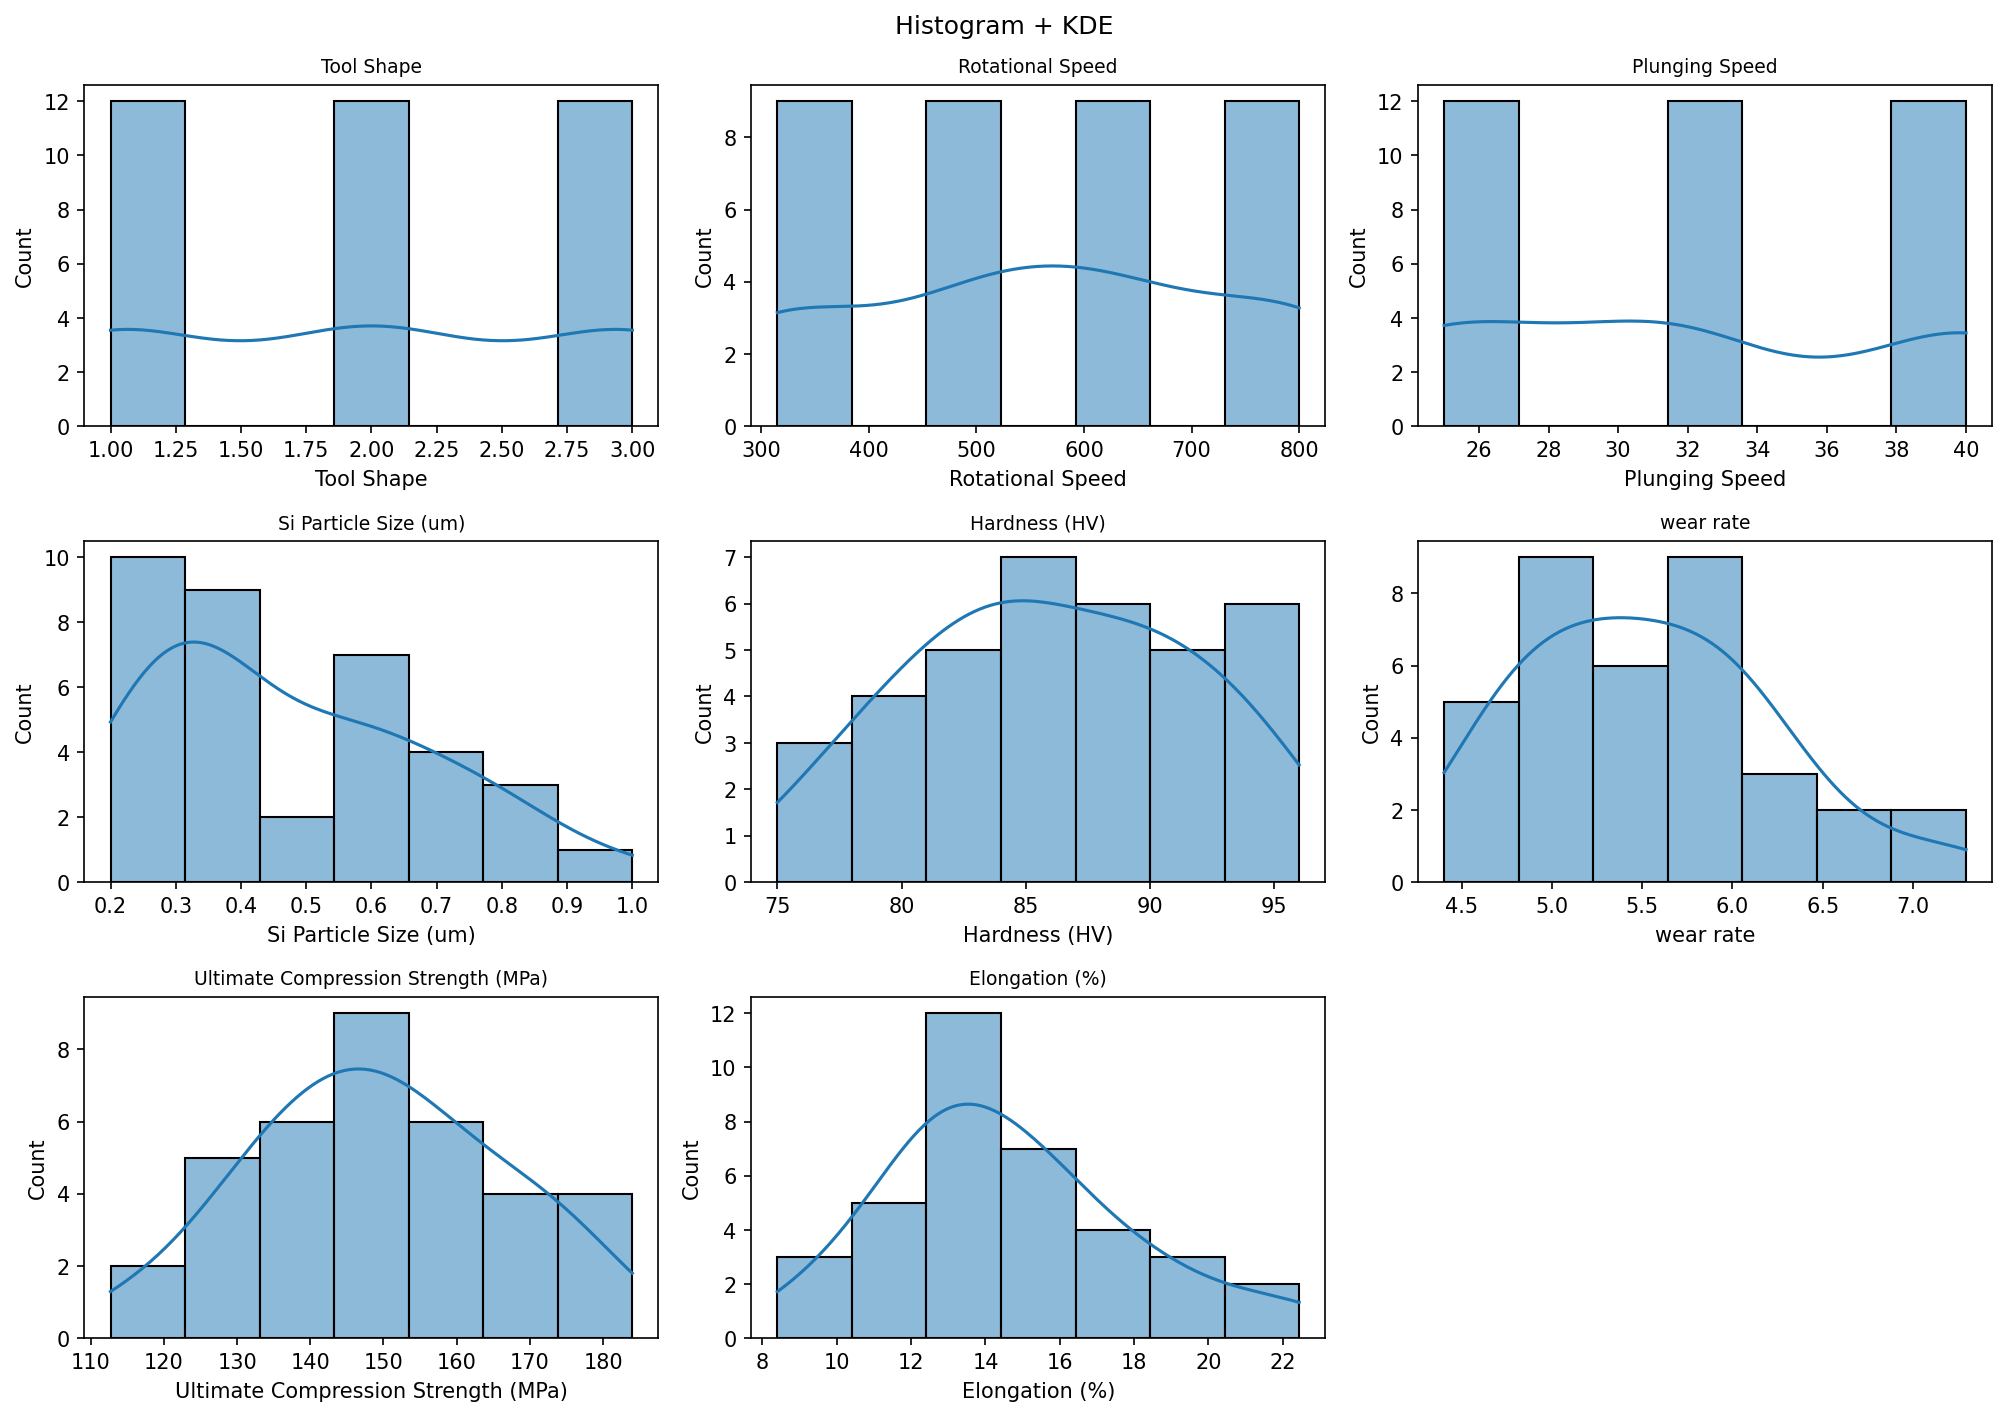

In [28]:
display(Image(filename=str(OUT_ROOT / 'Dataset_3772' / 'histograms_kde.png')))

Boxplot for every numeric variable.

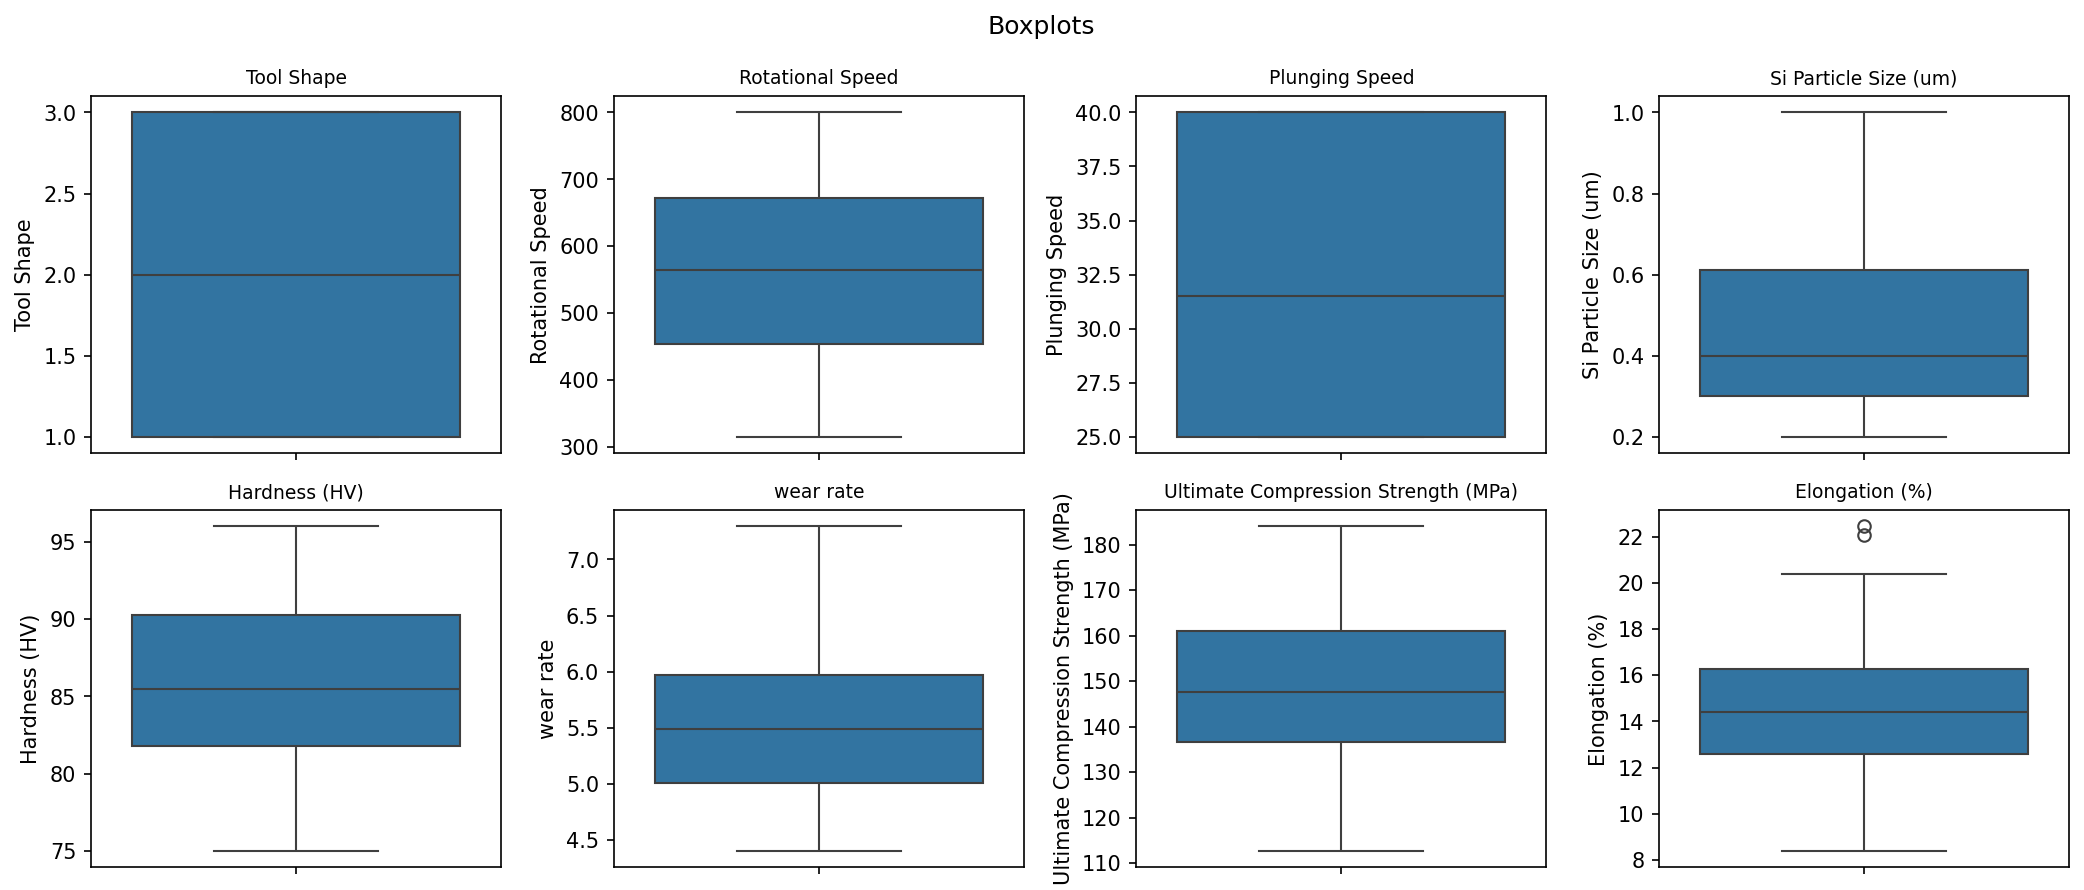

In [29]:
display(Image(filename=str(OUT_ROOT / 'Dataset_3772' / 'boxplots.png')))

QQ-plots against the normal distribution.

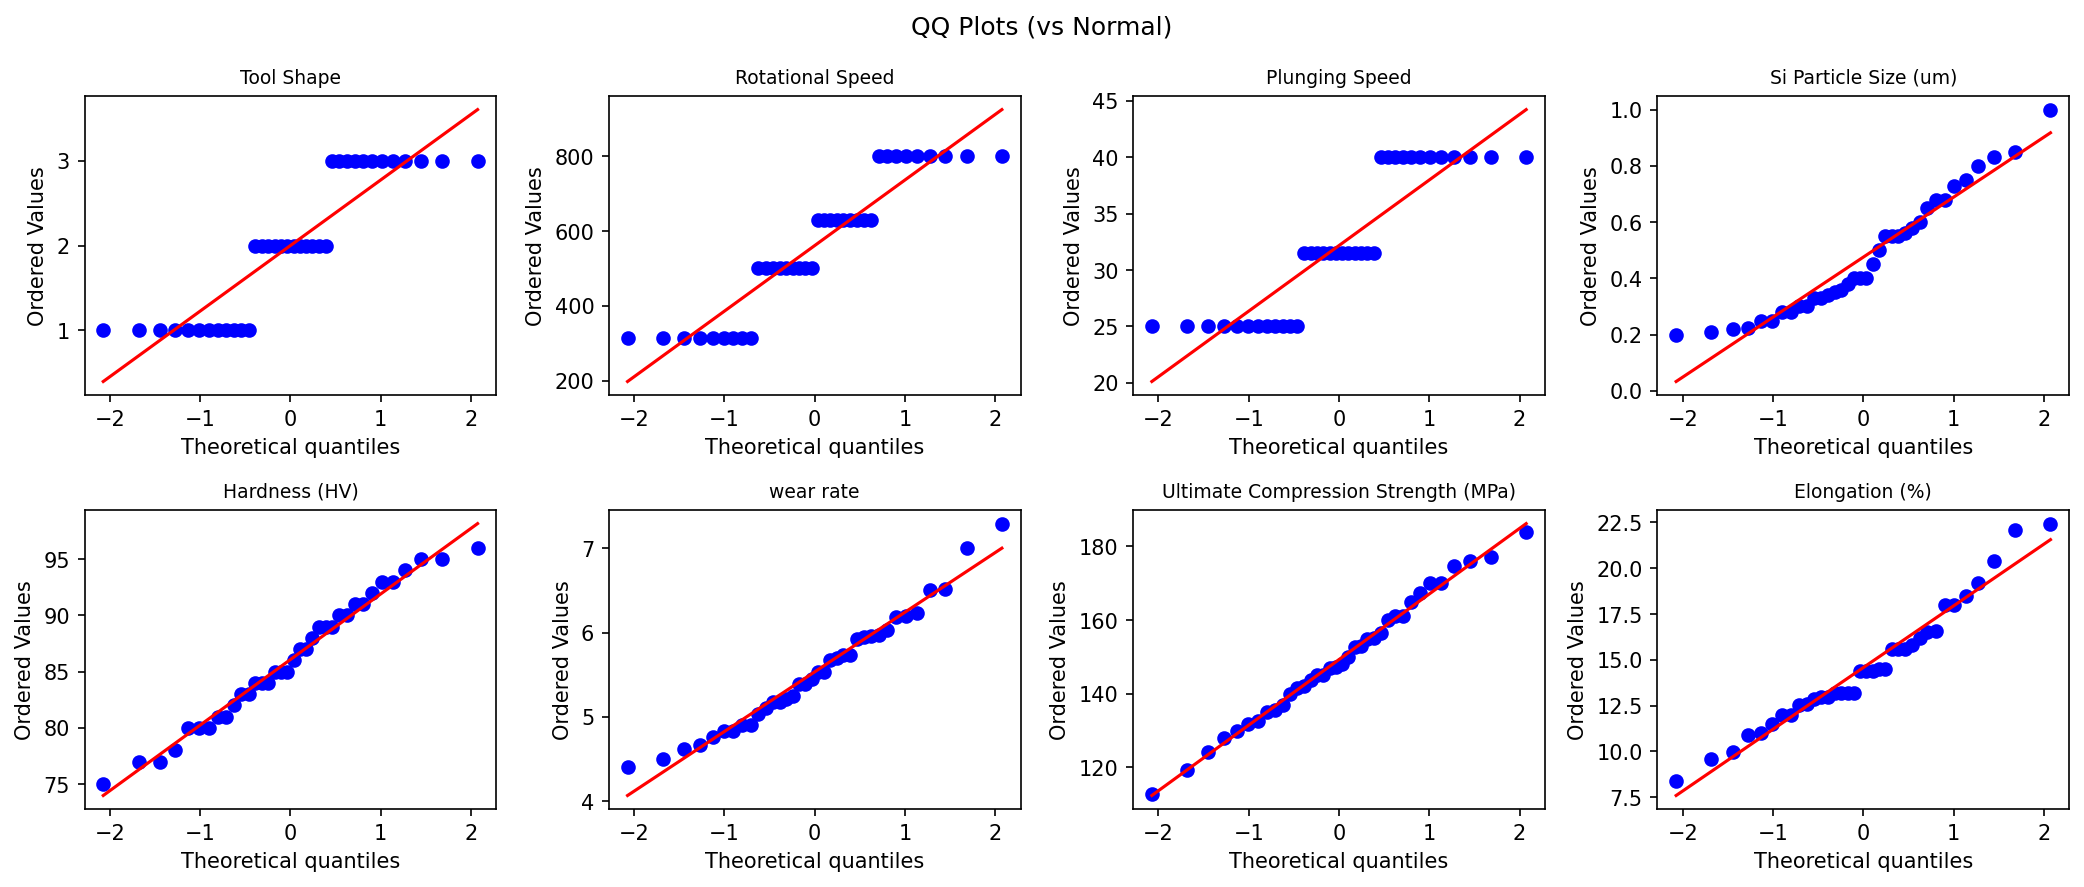

In [30]:
display(Image(filename=str(OUT_ROOT / 'Dataset_3772' / 'qq_plots.png')))

Pair plot of all numeric variables.

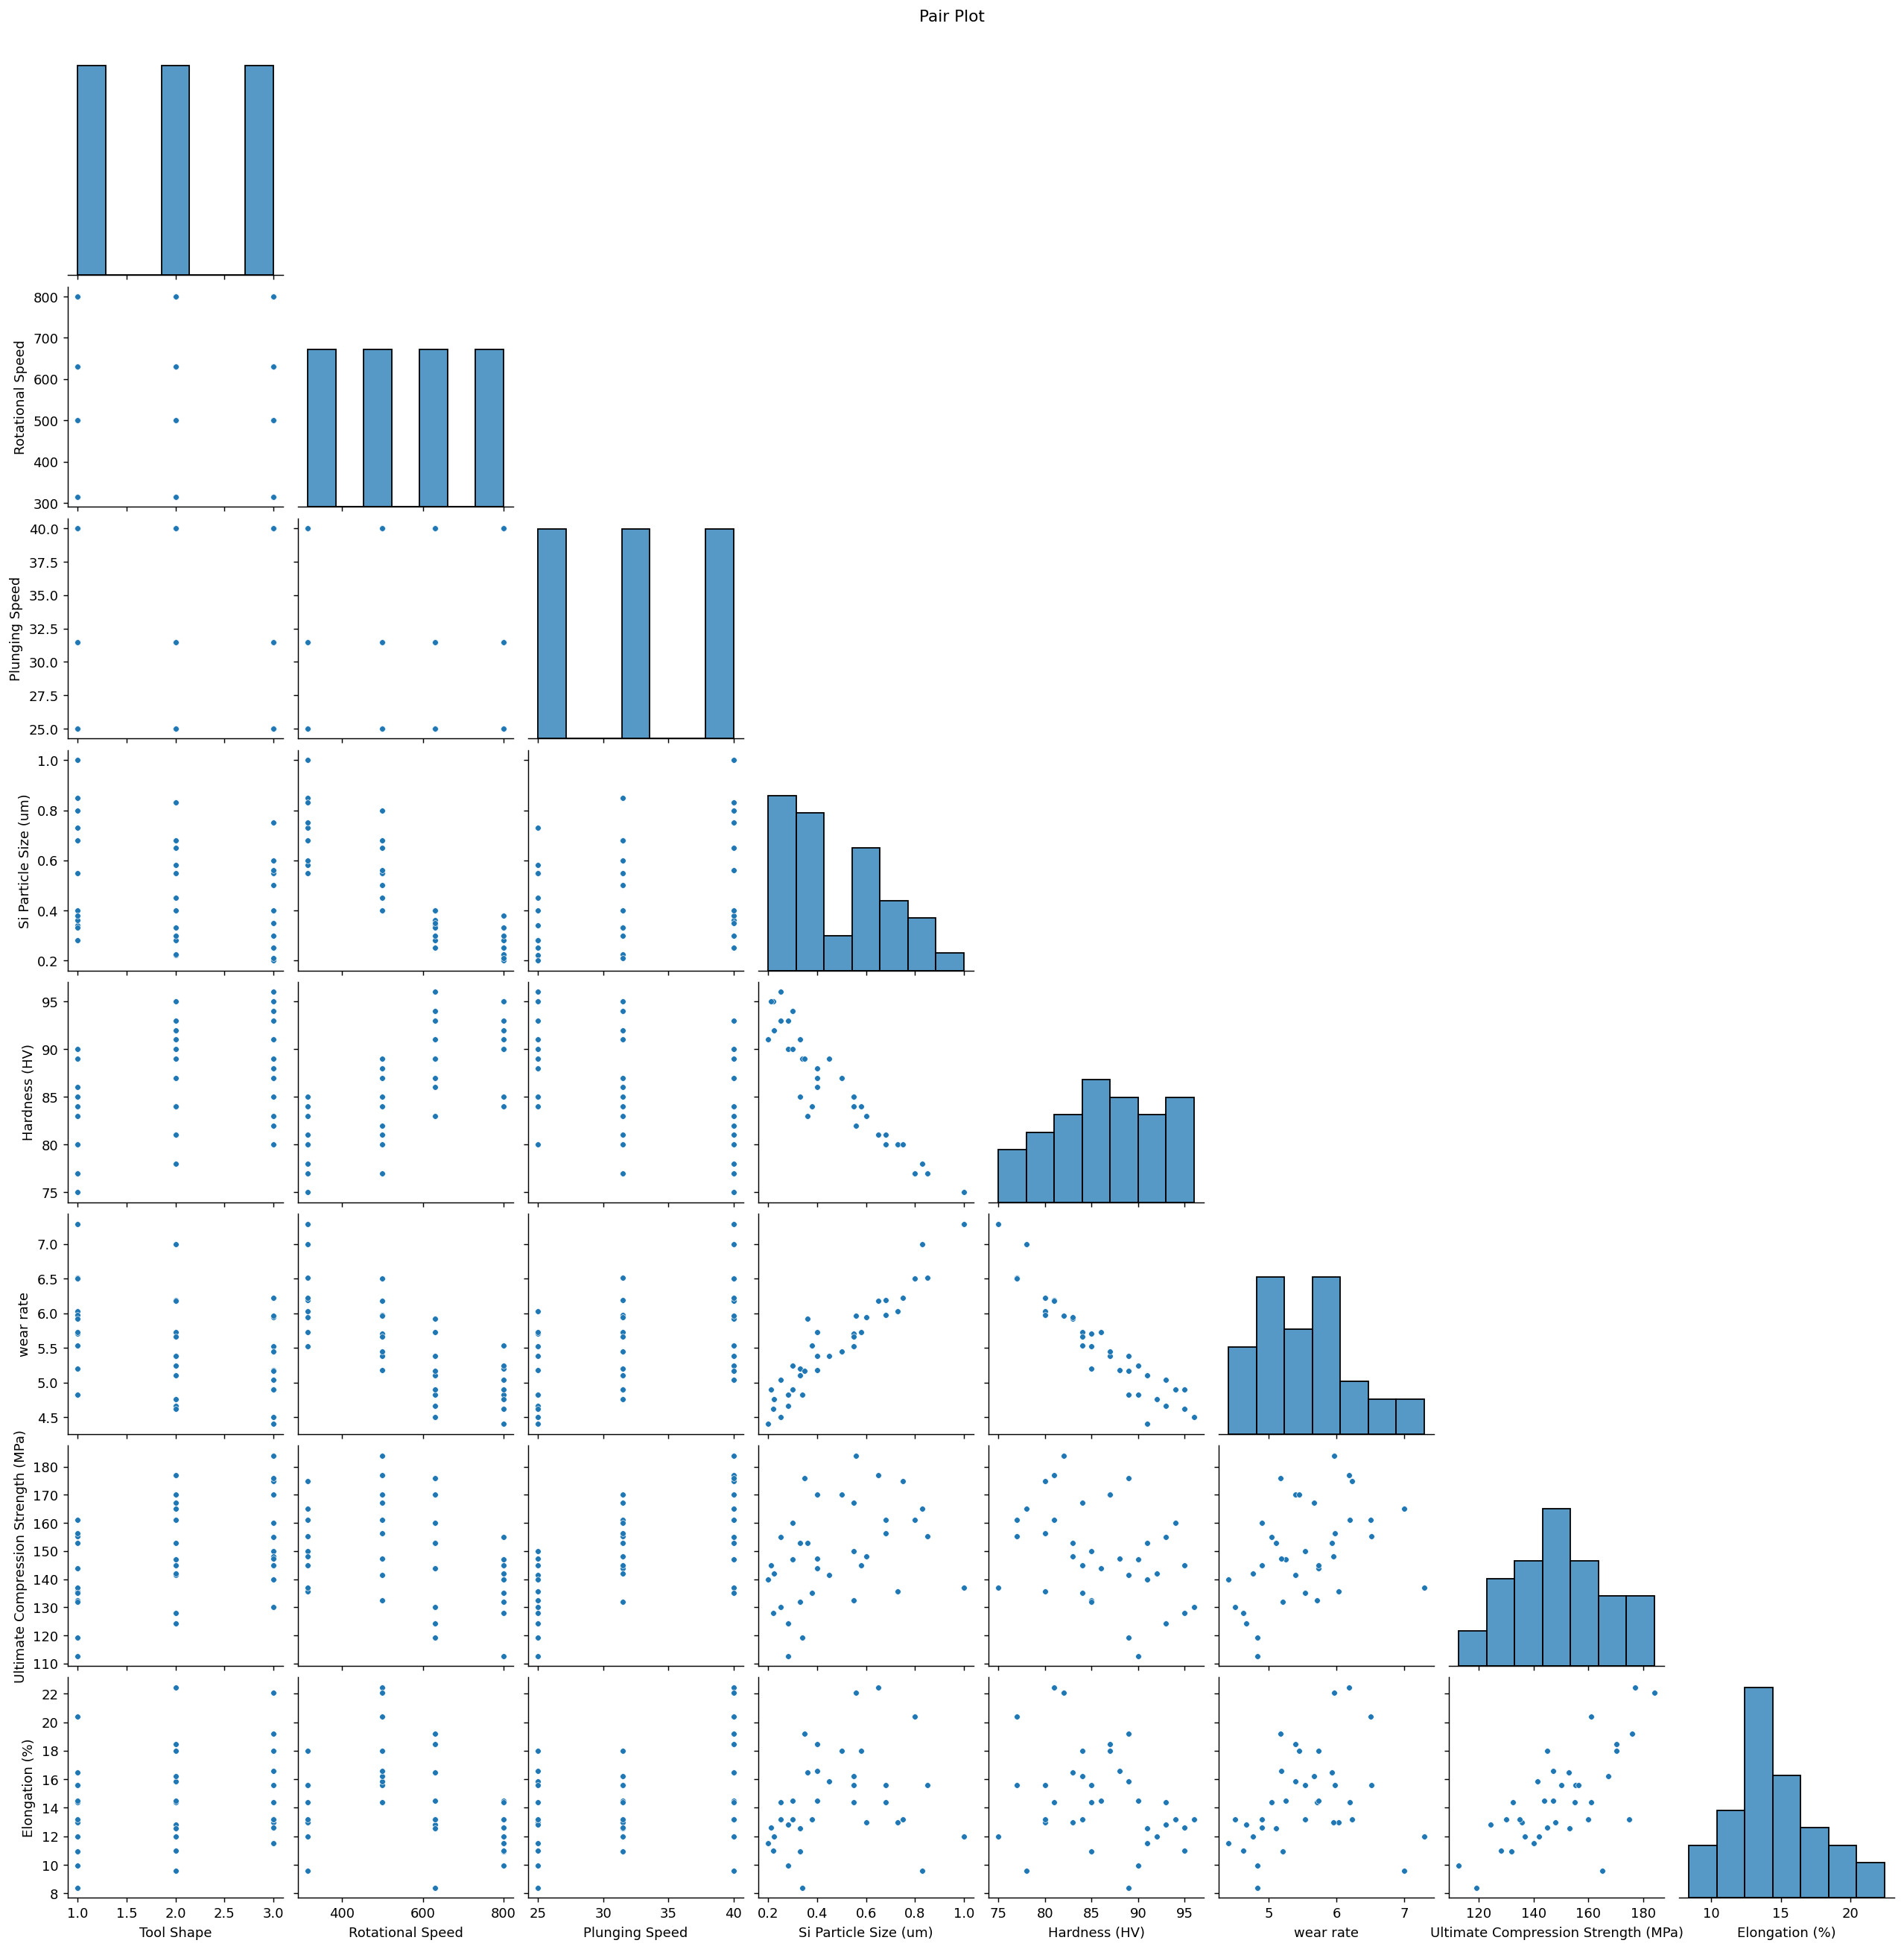

In [31]:
display(Image(filename=str(OUT_ROOT / 'Dataset_3772' / 'pairplot.png')))

Pearson / Spearman / Kendall correlation heatmaps.

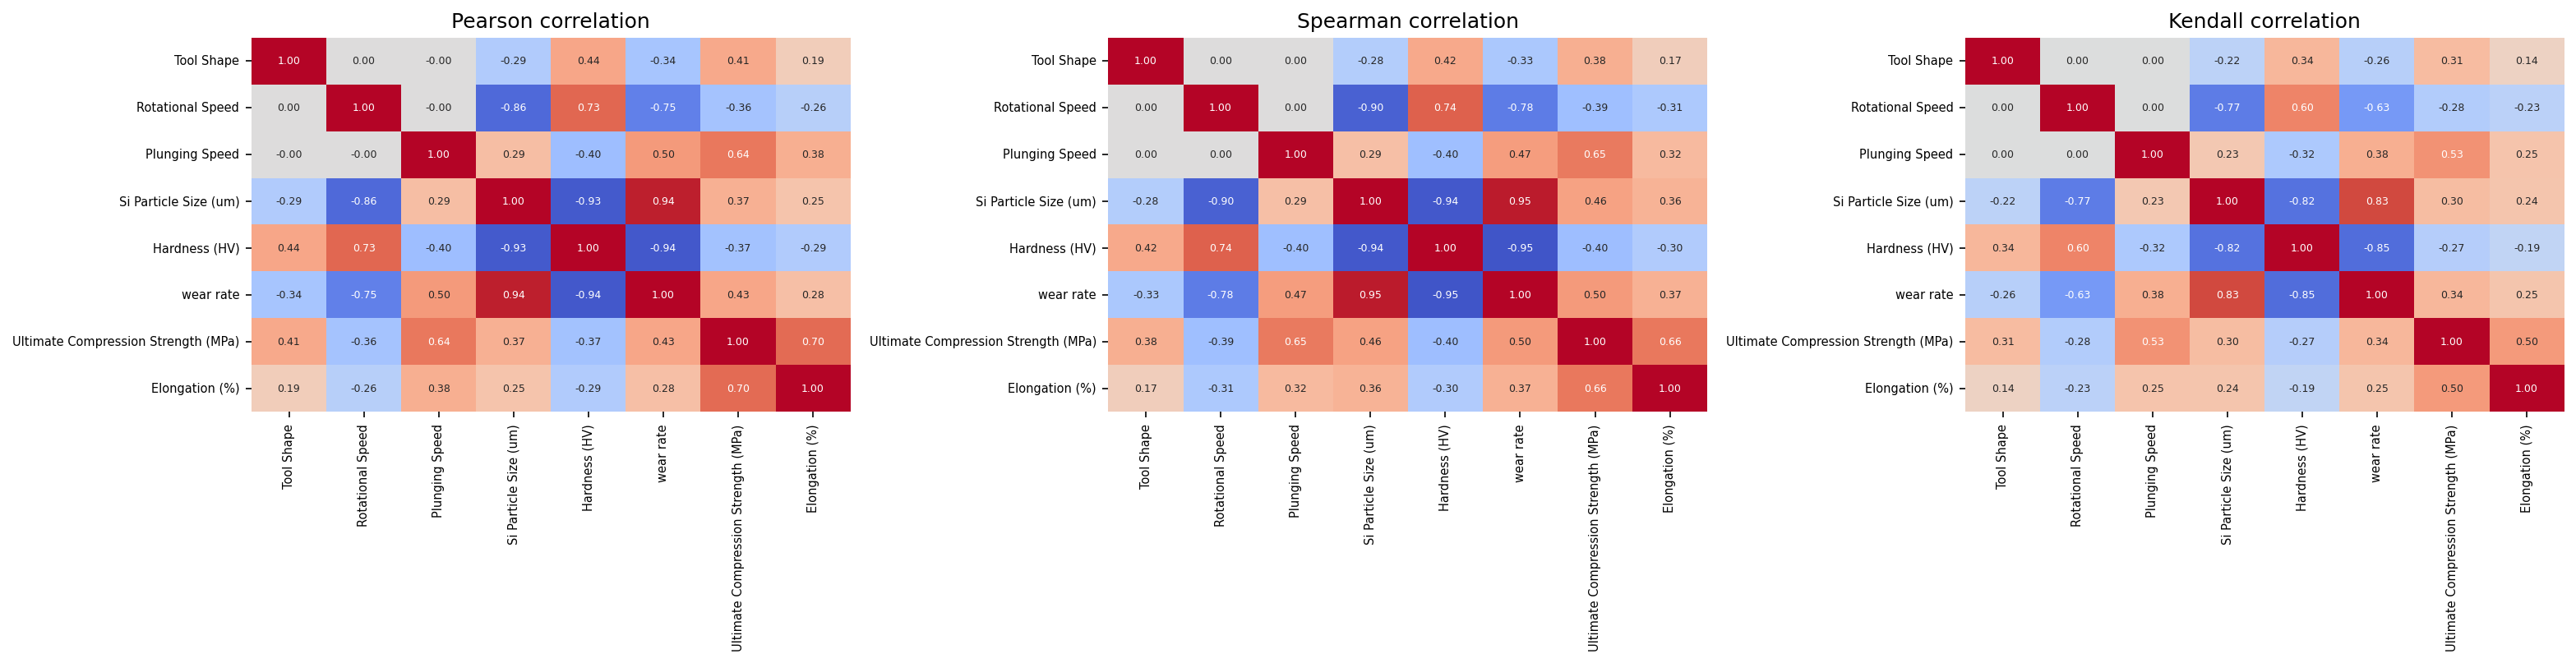

In [32]:
display(Image(filename=str(OUT_ROOT / 'Dataset_3772' / 'correlation_heatmaps.png')))

Descriptive statistics: mean, median, mode, variance, std, skewness, kurtosis.

In [33]:
desc_3772 = descriptive_statistics(df_3772)
desc_3772.to_csv(OUT_ROOT / 'Dataset_3772' / 'descriptive_statistics.csv')
desc_3772

,mean,median,mode,variance,std,skewness,kurtosis,min,max
Tool Shape,2.0000,2.000,1.0,0.6857,0.8281,0.0000,-1.5441,1.000,3.000
Rotational Speed,561.2500,565.000,315.0,32430.5357,180.0848,-0.0573,-1.2545,315.000,800.000
Plunging Speed,32.1667,31.500,25.0,38.8000,6.2290,0.1686,-1.5441,25.000,40.000
Si Particle Size (um),0.4754,0.400,0.4,0.0452,0.2126,0.6465,-0.4891,0.200,1.000
Hardness (HV),86.0833,85.500,80.0,32.2500,5.6789,-0.0471,-0.8995,75.000,96.000
wear rate,5.5356,5.488,4.9,0.4804,0.6931,0.5220,-0.0222,4.403,7.294
Ultimate Compression Strength (MPa),149.2925,147.600,145.0,297.9650,17.2617,0.0236,-0.5148,112.700,184.000
Elongation (%),14.5811,14.400,13.2,10.9716,3.3123,0.5910,0.1754,8.400,22.440


Normality tests: Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov.

In [34]:
norm_3772 = normality_tests(df_3772)
norm_3772.to_csv(OUT_ROOT / 'Dataset_3772' / 'normality_tests.csv', index=False)
norm_3772

,variable,shapiro_stat,shapiro_p,anderson_stat,anderson_crit_5pct,ks_stat,ks_p,normal_at_5pct(shapiro)
0,Tool Shape,0.7945,0.0000,2.8596,0.721,0.2197,0.0525,False
1,Rotational Speed,0.8617,0.0004,1.6647,0.721,0.1643,0.2564,False
2,Plunging Speed,0.7899,0.0000,2.9571,0.721,0.2291,0.0384,False
3,Si Particle Size (um),0.9321,0.0289,0.8034,0.721,0.1664,0.2434,False
4,Hardness (HV),0.9738,0.5375,0.2462,0.721,0.0851,0.9369,True
5,wear rate,0.9713,0.4624,0.2595,0.721,0.0765,0.9737,True
6,Ultimate Compression Strength (MPa),0.9899,0.9818,0.1147,0.721,0.0576,0.9992,True
7,Elongation (%),0.9651,0.3068,0.4641,0.721,0.1339,0.4971,True


Correlation tests (Pearson, Spearman, Kendall), sorted by absolute Spearman rho.

In [35]:
corr_3772 = correlation_tests(df_3772)
corr_3772.to_csv(OUT_ROOT / 'Dataset_3772' / 'correlation_tests.csv', index=False)
corr_3772.sort_values('spearman_rho', key=abs, ascending=False)

,var_a,var_b,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p
22,Hardness (HV),wear rate,-0.9399,0.0000,-0.9546,0.0000,-0.8498,0.0000
19,Si Particle Size (um),wear rate,0.9426,0.0000,0.9482,0.0000,0.8324,0.0000
18,Si Particle Size (um),Hardness (HV),-0.9270,0.0000,-0.9363,0.0000,-0.8169,0.0000
8,Rotational Speed,Si Particle Size (um),-0.8611,0.0000,-0.8964,0.0000,-0.7749,0.0000
10,Rotational Speed,wear rate,-0.7510,0.0000,-0.7774,0.0000,-0.6263,0.0000
9,Rotational Speed,Hardness (HV),0.7256,0.0000,0.7438,0.0000,0.5987,0.0000
27,Ultimate Compression Strength (MPa),Elongation (%),0.7025,0.0000,0.6554,0.0000,0.5012,0.0000
16,Plunging Speed,Ultimate Compression Strength (MPa),0.6440,0.0000,0.6469,0.0000,0.5322,0.0001
25,wear rate,Ultimate Compression Strength (MPa),0.4321,0.0085,0.4960,0.0021,0.3363,0.0040
15,Plunging Speed,wear rate,0.4998,0.0019,0.4749,0.0034,0.3821,0.0039


Bootstrap confidence intervals for Kendall's tau (95%).

In [36]:
kci_3772 = kendall_ci_table(df_3772)
kci_3772.to_csv(OUT_ROOT / 'Dataset_3772' / 'kendall_confidence_intervals.csv', index=False)
kci_3772

,var_a,var_b,tau,p_value,ci_lower,ci_upper
0,Tool Shape,Rotational Speed,0.0000,1.0000,-0.3073,0.2810
1,Tool Shape,Plunging Speed,0.0000,1.0000,-0.3054,0.2834
2,Tool Shape,Si Particle Size (um),-0.2243,0.0921,-0.4556,0.0460
3,Tool Shape,Hardness (HV),0.3370,0.0119,0.1017,0.5506
4,Tool Shape,wear rate,-0.2573,0.0519,-0.4788,-0.0215
5,Tool Shape,Ultimate Compression Strength (MPa),0.3094,0.0195,0.0727,0.5160
6,Tool Shape,Elongation (%),0.1359,0.3091,-0.1285,0.3728
7,Rotational Speed,Plunging Speed,0.0000,1.0000,-0.2946,0.2923
8,Rotational Speed,Si Particle Size (um),-0.7749,0.0000,-0.8496,-0.6684
9,Rotational Speed,Hardness (HV),0.5987,0.0000,0.4273,0.7244


Outlier detection with IQR, LOF and Isolation Forest — samples are flagged, never removed.

In [37]:
outl_3772 = outlier_report(df_3772)
outl_3772.to_csv(OUT_ROOT / 'Dataset_3772' / 'outlier_report.csv')
flagged_3772 = outl_3772[outl_3772['n_methods_flagging'] > 0]
print(f'{len(flagged_3772)} of {len(outl_3772)} samples flagged by at least one method')
flagged_3772

5 of 36 samples flagged by at least one method


,iqr_outlier,lof_outlier,iforest_outlier,n_methods_flagging
2,False,False,True,1
5,False,False,True,1
14,False,False,True,1
17,True,False,False,1
29,True,False,True,2


## Final Summary — Complete EDA Results (All Datasets)

All result tables combined across the three datasets, displayed in full and saved as `eda_summary_*.csv` files in `results/eda/`.

In [38]:
suffixes = {'Dataset_0136': '0136', 'Dataset_0172': '0172', 'Dataset_3772': '3772'}

def combine(frames, keep_index=False):
    parts = []
    for ds, f in frames.items():
        part = f.copy()
        if keep_index:
            part = part.reset_index().rename(columns={'index': 'variable'})
        part.insert(0, 'dataset', ds)
        parts.append(part)
    return pd.concat(parts, ignore_index=True)

summary_desc = combine({n: globals()[f'desc_{s}'] for n, s in suffixes.items()}, keep_index=True)
summary_norm = combine({n: globals()[f'norm_{s}'] for n, s in suffixes.items()})
summary_corr = combine({n: globals()[f'corr_{s}'] for n, s in suffixes.items()})
summary_kci = combine({n: globals()[f'kci_{s}'] for n, s in suffixes.items()})
summary_outl = pd.DataFrame([
    {'dataset': n,
     'n_samples': len(globals()[f'outl_{s}']),
     'n_flagged': int((globals()[f'outl_{s}']['n_methods_flagging'] > 0).sum()),
     'flagged_by_2plus': int((globals()[f'outl_{s}']['n_methods_flagging'] >= 2).sum())}
    for n, s in suffixes.items()
])

summary_desc.to_csv(OUT_ROOT / 'eda_summary_descriptive_statistics.csv', index=False)
summary_norm.to_csv(OUT_ROOT / 'eda_summary_normality_tests.csv', index=False)
summary_corr.to_csv(OUT_ROOT / 'eda_summary_correlation_tests.csv', index=False)
summary_kci.to_csv(OUT_ROOT / 'eda_summary_kendall_confidence_intervals.csv', index=False)
summary_outl.to_csv(OUT_ROOT / 'eda_summary_outlier_counts.csv', index=False)

print('=' * 90)
print('1) DESCRIPTIVE STATISTICS — all datasets')
print('=' * 90)
display(summary_desc)

print('=' * 90)
print('2) NORMALITY TESTS — all datasets')
print('=' * 90)
display(summary_norm)

print('=' * 90)
print('3) CORRELATION TESTS (Pearson / Spearman / Kendall) — all datasets')
print('=' * 90)
display(summary_corr)

print('=' * 90)
print('4) KENDALL TAU BOOTSTRAP CONFIDENCE INTERVALS — all datasets')
print('=' * 90)
display(summary_kci)

print('=' * 90)
print('5) OUTLIER SUMMARY — all datasets (flagged only, nothing removed)')
print('=' * 90)
display(summary_outl)

print()
print('All EDA results (figures + CSV tables) saved to:', OUT_ROOT.resolve())

1) DESCRIPTIVE STATISTICS — all datasets


,dataset,variable,mean,median,mode,variance,std,skewness,kurtosis,min,max
0,Dataset_0136,Tool Shape,2.0000,2.0000,1.0,0.6857,0.8281,0.0000,-1.5441,1.000,3.000
1,Dataset_0136,Rotational Speed,561.2500,565.0000,315.0,32430.5357,180.0848,-0.0573,-1.2545,315.000,800.000
2,Dataset_0136,Plunging Speed,32.1667,31.5000,25.0,38.8000,6.2290,0.1686,-1.5441,25.000,40.000
3,Dataset_0136,Si Particle Size (um),1.9072,1.7000,1.6,0.6917,0.8317,0.6290,-0.2167,0.800,4.100
4,Dataset_0136,Hardness (HV),80.9708,81.0000,81.0,31.6618,5.6269,-0.1688,-0.7005,69.000,91.000
5,Dataset_0136,wear rate,7.8866,7.7400,7.0,0.9650,0.9823,0.6071,0.1189,6.290,10.420
6,Dataset_0136,Ultimate Compression Strength (MPa),130.0639,130.5000,123.0,260.3681,16.1359,-0.1769,-0.7852,98.000,160.000
7,Dataset_0136,Elongation (%),12.2819,12.0000,11.0,7.9020,2.8111,0.4736,-0.2403,7.500,18.700
8,Dataset_0136,Temperature (°C),363.0833,356.0000,353.0,946.8786,30.7714,0.4640,-0.5452,310.000,430.000
9,Dataset_0136,Strain,89.3028,86.5000,50.0,682.6106,26.1268,0.4502,-0.6964,50.000,148.000


2) NORMALITY TESTS — all datasets


,dataset,variable,shapiro_stat,shapiro_p,anderson_stat,anderson_crit_5pct,ks_stat,ks_p,normal_at_5pct(shapiro)
0,Dataset_0136,Tool Shape,0.7945,0.0000,2.8596,0.721,0.2197,0.0525,False
1,Dataset_0136,Rotational Speed,0.8617,0.0004,1.6647,0.721,0.1643,0.2564,False
2,Dataset_0136,Plunging Speed,0.7899,0.0000,2.9571,0.721,0.2291,0.0384,False
3,Dataset_0136,Si Particle Size (um),0.9444,0.0698,0.5852,0.721,0.1441,0.4051,True
4,Dataset_0136,Hardness (HV),0.9793,0.7214,0.2110,0.721,0.0854,0.9353,True
5,Dataset_0136,wear rate,0.9687,0.3900,0.2916,0.721,0.0753,0.9772,True
6,Dataset_0136,Ultimate Compression Strength (MPa),0.9792,0.7181,0.1949,0.721,0.0664,0.9942,True
7,Dataset_0136,Elongation (%),0.9704,0.4366,0.3100,0.721,0.1203,0.6316,True
8,Dataset_0136,Temperature (°C),0.9657,0.3204,0.4342,0.721,0.1212,0.6225,True
9,Dataset_0136,Strain,0.9581,0.1881,0.4567,0.721,0.1201,0.6333,True


3) CORRELATION TESTS (Pearson / Spearman / Kendall) — all datasets


...

4) KENDALL TAU BOOTSTRAP CONFIDENCE INTERVALS — all datasets


,dataset,var_a,var_b,tau,p_value,ci_lower,ci_upper
0,Dataset_0136,Tool Shape,Rotational Speed,0.0000,1.0000,-0.3073,0.2810
1,Dataset_0136,Tool Shape,Plunging Speed,0.0000,1.0000,-0.3054,0.2834
2,Dataset_0136,Tool Shape,Si Particle Size (um),-0.2404,0.0717,-0.4756,0.0319
3,Dataset_0136,Tool Shape,Hardness (HV),0.3467,0.0093,0.1047,0.5620
4,Dataset_0136,Tool Shape,wear rate,-0.2419,0.0675,-0.4633,-0.0020
5,Dataset_0136,Tool Shape,Ultimate Compression Strength (MPa),0.3156,0.0173,0.0533,0.5435
6,Dataset_0136,Tool Shape,Elongation (%),0.1845,0.1675,-0.0814,0.4309
7,Dataset_0136,Tool Shape,Temperature (°C),-0.1728,0.1916,-0.4305,0.0935
8,Dataset_0136,Tool Shape,Strain,0.1418,0.2831,-0.1239,0.3887
9,Dataset_0136,Rotational Speed,Plunging Speed,0.0000,1.0000,-0.2946,0.2923


5) OUTLIER SUMMARY — all datasets (flagged only, nothing removed)


,dataset,n_samples,n_flagged,flagged_by_2plus
0,Dataset_0136,36,4,0
1,Dataset_0172,72,9,1
2,Dataset_3772,36,5,1



All EDA results (figures + CSV tables) saved to: C:\Users\mohammadhosein\Desktop\DeepLearning-miniProject\results\eda
